### prepair modules and bases settings

In [319]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix,  classification_report, log_loss
from sklearn.preprocessing import StandardScaler
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.svm import SVC
# from sklearn.ensemble import RandomForestClassifier
from scipy.stats import norm
import scipy.io
import re
import itertools

import os
from os.path import join
import contextlib
from copy import deepcopy
import imp 
import time 
import sys

import pickle
from pdb import set_trace

from IPython.display import clear_output, display

In [2]:
# Add the directory containing your modules to the Python path
sys.path.append(os.path.abspath(os.path.join('..', 'ses2_modelstims')))

# load local functions
import stim_io
import stim_io_plotting
import vtc
import bvbabel

/home/jorvhar/miniconda3/envs/predlis/lib/python3.8/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '


In [3]:
import regression
import varpar
import stats

In [4]:
## LOADING GRID

# Load from MAT file
variables = scipy.io.loadmat('/media/jorvhar/Data8T/MRIData/timing data/grid_parameters_python.mat')

# Extract individual variables
tunsteps = variables['tunsteps']
freqstep = variables['freqstep']
subsample = variables['subsample']
mustep = variables['mustep']
muarray_bins = variables['muarray_bins']
muarray = variables['muarray']
fwhm = variables['fwhm']
octgrid = variables['octgrid']
sigmagrid = variables['sigmagrid']
pref_range = variables['pref_range']
sharp_range_fwhm = variables['sharp_range_fwhm']
sharp_range = variables['sharp_range']

## 1. Load Regression Parameters for easier parsing
Options:

In [5]:
### --- LOCATION OPTIONS ---

# file location
mridat_dir = '/media/jorvhar/Data8T/MRIData/PreProc'

# tonotopy and mask filenames
tonotopy_vmp = 'prf_permutations_for_s2.vmp'
mask_fn = 'gm-subcortical.msk'
pp_dir = lambda pp, ses : f'S{pp:02d}_SES{ses}'

### --- PARTICIPANT OPTIONS ---

# session of interest
ses = 2

# variable that may be different per participant
ppz = [1,2,3,4,5,6,7,8,9,10]
n_splitsz = [6,6,5,5,5,5,5,5,5,5]               # 12 runs > 10:2cross, 6 fold, splits used per pp (for variable length option)
n_runz = [12,12,10,10,10,10,10,10,10,10]        # number of runs
startpp = 1

### --- SET THEORIE REGRESSION MODELS ---

# for full 3 sets we need 7 sets
models = ['base',
          'adaptation',
          'prediction',
          'base_U_adaptation',
          'base_U_prediction',
          'adaptation_U_prediction',
          'base_U_adaptation_U_prediction']
# models = ['prediction',
#           'base_U_adaptation',
#           'base_U_adaptation_U_prediction']
# if we want to use sets we only need 3 models 
##models=['base_U_adaptation', 'prediction', 'base_U_adaptation_U_prediction']

## REGRESSORS IN MODELS ##
model_regressors = {'base':       ['raw_acti', 'onoff'], 
                    'adaptation': ['raw_adapt' ],      # adaptation
                    'prediction': ['pred_prob',   # voxelwise prior liklihood
                                   'surprisal',
                                   'precision']   # global prior surprise
                   } 
# if we want to add adapted activation
# model_regressors['adaptation'] += ['adapt_activ']

# set combination of regressors
model_regressors.update({'base_U_adaptation':             model_regressors['base']+
                                                          model_regressors['adaptation'],
                        'base_U_prediction':              model_regressors['base']+
                                                          model_regressors['prediction'], 
                        'adaptation_U_prediction':        model_regressors['adaptation']+
                                                          model_regressors['prediction'], 
                        'base_U_adaptation_U_prediction': model_regressors['base']+
                                                          model_regressors['adaptation']+
                                                          model_regressors['prediction']})

## 2. Sanity check score results

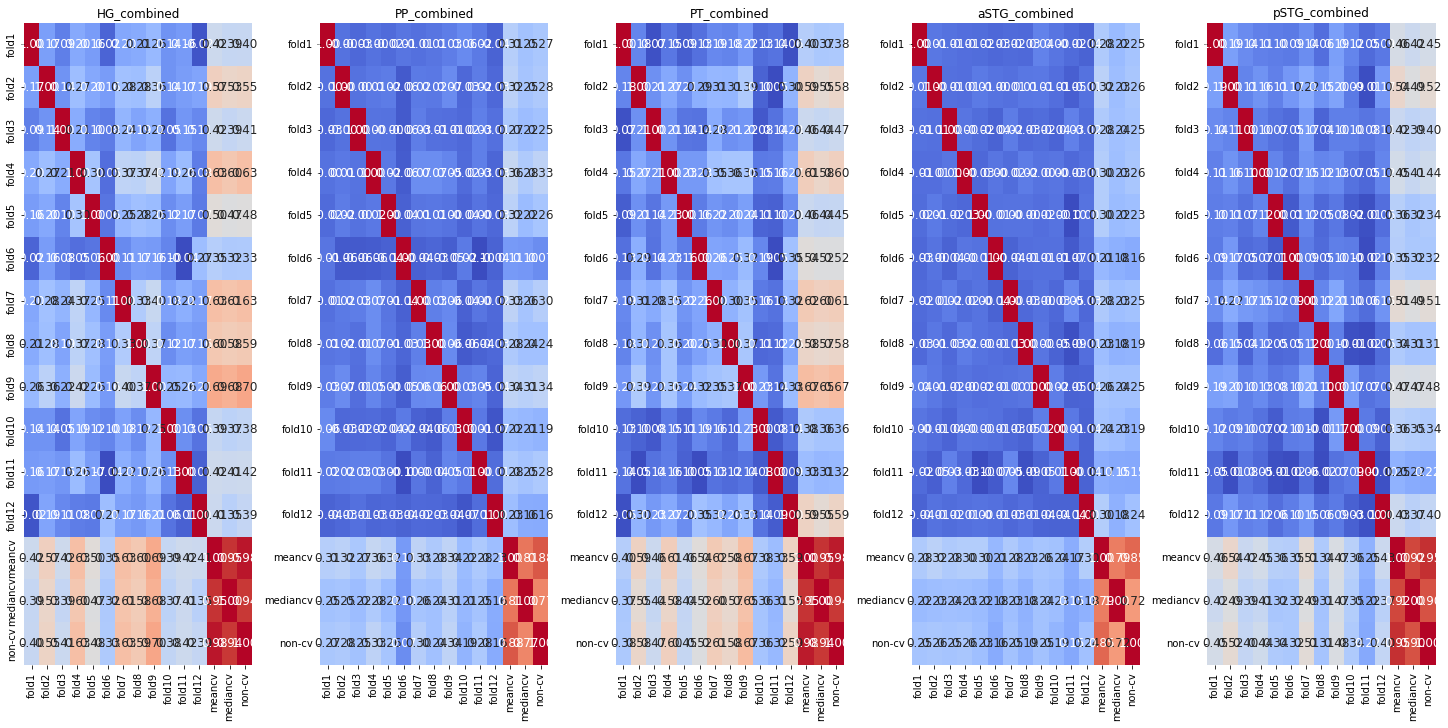

In [93]:
pp = 1
scores_fn = 'ANTS_scores_pw_uw_er_lwo_tempsmooth'

# 'ANTS_scores_pw_uw_fixed_tempsmooth'
# 'ANTS_IdealObserver_scores_pw_uw_tempsmooth'
# 'ANTS_IdealObserver_predictors_split_pw_uw_tempsmooth'

betas_dir = 'Betas'
model = 'prediction'

# set ROIS
rois = ['HG', 'PP', 'PT', 'aSTG', 'pSTG']
rois_sel = ['HG_combined', 'PP_combined', 'PT_combined', 'aSTG_combined', 'pSTG_combined']
hemispheres = ['LH', 'RH', 'combined']
layers = ['Layer 1', 'Layer 2', 'Layer 3']

# loop over rois
fig, axes = plt.subplots(1, len(rois_sel), figsize=(20, 10), constrained_layout=True)

# set theme
sns.set_theme(style="white")

# open pickle of vois (see ROI_and_layer_ana notebook)
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
# and of results
with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
    scores = pickle.load(handle)

# get fold dict
fold_dict = {f'fold{fold}': scores[model][fold]['raw_scores'] for fold in scores['base'].keys() if isinstance(fold, (int, float))}
# get mean, median and noncv dict
other_dict = {'meancv': scores[model]['raw_scores']['mean'],
              'mediancv': scores[model]['raw_scores']['median'],
              'non-cv': scores[model]['non-cv']['raw_scores']}
df_dict = {**fold_dict, **other_dict}

# get indexes
indx_dict_nl = stim_io.generate_voxel_indices(hemispheres, rois, voi_dict, scores['indexes'])

# load dataframe
df = pd.DataFrame(df_dict)

for ax, roi in zip(axes, rois_sel):

    # current indexes
    indxs = indx_dict_nl[roi]

    # sel df
    dfsel = df.iloc[indxs]

    # Calculate correlations including meancv and non-cv
    extended_corr = dfsel.corr()

    # Plot heatmap
    sns.heatmap(extended_corr, annot=True, cmap="coolwarm", cbar=False, fmt=".2f", ax=ax)
    ax.set_title(f"{roi}")

plt.show()


## 3. Saving `_coeffs` (Betas) and `R2S` (variance) average within participants
We loop over all participants and save:
* The average Beta weights per participant per model - for all regressors within this model (save as dict of pd)
* The average of the R2 components within the full model (Base, Base_U_Pred, Pred_unqiue etc.)

note: we can look up the `regressor labels` by using `scores['prediction']['feature_labels']`

In [518]:
# first r2s

import matplotlib.pyplot as plt
import numpy as np

# set ROIS
rois = ['HG', 'PP', 'PT', 'aSTG', 'pSTG']
hemispheres = ['LH', 'RH', 'combined']
layers = ['Layer 1', 'Layer 2', 'Layer 3']

# create lamdas for dict
roisLambda = lambda hs: f'{hs}_auditory.voi'
boundaryLambda = lambda hs: f'{hs}_boundary.voi'
depthLambda = lambda hs: f'winning_WMGM_{hs}_D1-3.voi'

# selmodel: 'base_U_adaptation_U_prediction'  
#           'base_U_prediction_prior_U_prediction_error'
# filename: 'ANTS_scores_pw_uw_lwo_tempsmooth'  
#           'ANTS_scores_pw_uw_lwo'
#           'ANTS_IdealObserver_scores_pw_uw_lwo_tempsmooth'
#           'ANTS_predictors_split_prec_pw_lwo_tempsmooth'
#           'ANTS_IdealObserver_predictors_split_prec_lwo_tempsmooth'

selmodel = 'base_U_adaptation_U_prediction' #'base_U_adaptation_U_prediction' # base_U_prediction_prior_U_prediction_error
threshold_p = 0.05
scores_fn = 'ANTS_scores_pw_uw_er_lwo_tempsmooth' # or 'scores_tempsmooth' or 'IdealObserver_scores_tempsmooth' 
# scores_fn = 'ANTS_IdealObserver_scores_pw_uw_lwo_tempsmooth' # or 'scores_tempsmooth' or 'IdealObserver_scores_tempsmooth' 
ppz = [1,2,3,4,5,6,7,8,9,10]

# other parameters
correct_r2s = False
cv = True
cvmethod = 'median'
handle_negatives = 'aubuc_remove' #'zero', 'zero_partials', 'remove', 'aubuc_remove'

# get full grida
grid = list(itertools.product(rois, hemispheres))

# initialize an empty DataFrame for storing means
average_df = pd.DataFrame()

# loop over participants
for pp_idx, pp in enumerate(ppz):
    
    print(f'Participant: {pp}')
    
    # open pickle of vois
    with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset_winning.pickle'), 'rb') as handle:
        voi_dict = pickle.load(handle)
    # and of results
    with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
        scores = pickle.load(handle)
        
    # sellect models
    models = list(scores.keys())[:-1]
        
    # get indexes
    indx_dict = stim_io.generate_voxel_indices(hemispheres, rois, voi_dict, scores['indexes'], layers=layers, depthLambda=depthLambda) 
    # do another sweep without layers
    # get indexes
    indx_dict_nl = stim_io.generate_voxel_indices(hemispheres, rois, voi_dict, scores['indexes'], depthLambda=depthLambda)
    
    # Loop over ROIs
    for i, gp in enumerate(grid):
        
        # get combined index
        roi = f'{gp[0]}_{gp[1]}'
        
        # loop over layers
        for ly_idx, layer in enumerate(layers):
        
            # Get subgroup of good performing voxels
            subidx = np.where(scores[selmodel]['non-cv']['p_value'][indx_dict[roi][layer]] < threshold_p)
            newidx = indx_dict[roi][layer][subidx]
            
            # Get score selection
            if cv:
                score_sel = {model: scores[model]['raw_scores'][cvmethod][newidx] for model in models}   #cv-mean
            else:
                score_sel = {model: scores[model]['non-cv']['raw_scores'][newidx] for model in models}   #noncv
                
            # get cv scores
            set3 = varpar.three_way_varpart(score_sel[models[0]],
                                          score_sel[models[1]],
                                          score_sel[models[2]],
                                          score_sel[models[3]],
                                          score_sel[models[4]],
                                          score_sel[models[5]],
                                          score_sel[models[6]],
                                          correct_R2s=correct_r2s,  # correct true or false
                                          handle_negatives=handle_negatives)
            df = varpar.organize_varpar_to_df(set3, nvars=3, lbls=[models[0],models[1],models[2]])
            
            # print info
            print(f'len {gp}/{layer} is {len(newidx)} [With negatives removed: {len(df)}]')
            
            # [NEW] mask out impossible vallues
#             msk = varpar.mask_varpart_impossible(df)
#             df = df.loc[msk == 1]
            
#             # calculate 2-way varpar for crossvalidated
#             set2 = varpar.two_way_varpart(score_sel['base_U_adaptation'],
#                                                 score_sel['prediction'],
#                                                 score_sel['base_U_adaptation_U_prediction'],
#                                                 correct_R2s=True, return_sep=True)
#             df = varpar.organize_varpar_to_df(set2, lbls=['Baseline','Expectation'], nvars=2)

            # append to average dataframe
            mean_series = df.mean()
            mean_series['pp'] = pp
            mean_series['roi'] = roi
            mean_series['layer'] = layer
            average_df = average_df._append(mean_series, ignore_index=True)
        
        # Get subgroup of good performing voxels
        subidx = np.where(scores[selmodel]['non-cv']['p_value'][indx_dict_nl[roi]] < threshold_p)
        newidx = indx_dict_nl[roi][subidx]

        # get varpart labels
        models = list(score_sel.keys())
        
        # Get score selection
        if cv:
            score_sel = {model: scores[model]['raw_scores'][cvmethod][newidx] for model in models}   #cv-mean
        else:
            score_sel = {model: scores[model]['non-cv']['raw_scores'][newidx] for model in models}   #noncv

        # get cv scores
        set3 = varpar.three_way_varpart(score_sel[models[0]],
                                        score_sel[models[1]],
                                        score_sel[models[2]],
                                        score_sel[models[3]],
                                        score_sel[models[4]],
                                        score_sel[models[5]],
                                        score_sel[models[6]],
                                        correct_R2s=correct_r2s,  # correct true or false
                                        handle_negatives=handle_negatives)
        df = varpar.organize_varpar_to_df(set3, nvars=3, lbls=[models[0],models[1],models[2]])

#             # calculate 2-way varpar for crossvalidated
#             set2 = varpar.two_way_varpart(score_sel['base_U_adaptation'],
#                                                 score_sel['prediction'],
#                                                 score_sel['base_U_adaptation_U_prediction'],
#                                                 correct_R2s=True, return_sep=True)
#             df = varpar.organize_varpar_to_df(set2_noncv, lbls=['Baseline','Expectation'], nvars=2)

        # append to average dataframe
        mean_series = df.mean()
        mean_series['pp'] = pp
        mean_series['roi'] = roi
        mean_series['layer'] = 'combined'
        average_df = average_df._append(mean_series, ignore_index=True)
    
# get filename for r2s
if correct_r2s: corrected_fn = 'corrected'
else: corrected_fn = 'uncorrected'

# get filename for cv
if cv: cv_fn = f'cv({cvmethod})'
else: cv_fn = 'noncv'
    
average_df.to_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle')) 

# average_df.to_pickle(join(mridat_dir, 'R2S_df_dict_uncorrected_noncv_set3_inset.pickle')) 
# average_df = pd.read_pickle(join(mridat_dir, 'R2S_df_dict_set3.pickle'))  

Participant: 1


KeyboardInterrupt: 

In [530]:
# then coeffs

# set ROIS
rois = ['HG', 'PP', 'PT', 'aSTG', 'pSTG']
hemispheres = ['LH', 'RH', 'combined']
layers = ['Layer 1', 'Layer 2', 'Layer 3']

# create lamdas for dict
roisLambda = lambda hs: f'{hs}_auditory.voi'
boundaryLambda = lambda hs: f'{hs}_boundary.voi'
depthLambda = lambda hs: f'WMGM_{hs}_D1-3.voi'

selmodel = 'base_U_adaptation_U_prediction' #base, base_U_adaptation_U_prediction
threshold_p = 0.001
scores_fn = 'ANTS_scores_pw_uw_er_lwo_tempsmooth' # or 'scores_tempsmooth' or 'IdealObserver_scores_tempsmooth' 
ppz = [1,2,3,4,5,6,7,8,9,10]

# other parameters
cv = True
cvmethod = 'median'

# get full grid
grid = list(itertools.product(rois, hemispheres))

# initialize an empty DataFrame for storing means
coef_df = {}

# get regressor order
col_names = stim_io.get_collumn_order()

# loop over all models
for model in model_regressors.keys():
    
    print(f'Model: {model}')

    # empty df for model
    coef_df[model] = pd.DataFrame()
    
    # loop over all participants
    for pp_idx in np.arange(ppz.index(startpp),len(ppz)):

        # fetch current pp vars
        pp = ppz[pp_idx]
        print(f' -{pp}')

        # open pickle of vois
        with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
            voi_dict = pickle.load(handle)
        # and of results
        with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
            scores = pickle.load(handle)

        # get indexes
        indx_dict = stim_io.generate_voxel_indices(hemispheres, rois, voi_dict, scores['indexes'], layers=layers)
        # and for non layers
        indx_dict_nl = stim_io.generate_voxel_indices(hemispheres, rois, voi_dict, scores['indexes'])

        # predifine dict
        fullregdict = {}

        # get correct order of betas
#         reordered_regs = [item for item in col_names if item in model_regressors[model]]  #old, use new method instead
        reordered_regs = scores[model]['feature_labels']

        # Loop over ROIs
        for i, gp in enumerate(grid):

            # get combined index
            roi = f'{gp[0]}_{gp[1]}'

            # loop over layers
            for ly_idx, layer in enumerate(layers):

                # Get subgroup of good performing voxels
                subidx = np.where(scores[selmodel]['non-cv']['p_value'][indx_dict[roi][layer]] < threshold_p)
                newidx = indx_dict[roi][layer][subidx]

                # create regname in dicts
                if cv:
                    score_sel = {f'{it}' : scores[model]['coefs'][cvmethod][newidx,it_idx] for       # cv
                                 it_idx, it in enumerate(reordered_regs)}
                else:
                    score_sel = {f'{it}' : scores[model]['non-cv']['coefs'][newidx,it_idx] for     # non-cv
                                 it_idx, it in enumerate(reordered_regs)}
                df = pd.DataFrame(score_sel)
        
                # append to average dataframe
                mean_series = df.mean()
                mean_series['pp'] = pp
                mean_series['roi'] = roi
                mean_series['layer'] = layer
                coef_df[model] = coef_df[model]._append(mean_series, ignore_index=True)
        
            # Get subgroup of good performing voxels
            subidx = np.where(scores[selmodel]['non-cv']['p_value'][indx_dict_nl[roi]] < threshold_p)
            newidx = indx_dict_nl[roi][subidx]
  
            # create regname in dicts
            if cv:
                cv_fn = f'cv({cvmethod})'
                score_sel = {f'{it}' : scores[model]['coefs'][cvmethod][newidx,it_idx] for 
                             it_idx, it in enumerate(reordered_regs)}
            else:
                cv_fn = 'non-cv'
                score_sel = {f'{it}' : scores[model]['non-cv']['coefs'][newidx,it_idx] for     # non-cv
                             it_idx, it in enumerate(reordered_regs)}
            df = pd.DataFrame(score_sel)
        
            # append to average dataframe
            mean_series = df.mean()
            mean_series['pp'] = pp
            mean_series['roi'] = roi
            mean_series['layer'] = 'combined'
            coef_df[model] = coef_df[model]._append(mean_series, ignore_index=True)
    
with open(join(mridat_dir, f'coeffs_{scores_fn}_{cv_fn}_dict(p{threshold_p:.0e}).pickle'), 'wb') as handle:
    pickle.dump(coef_df, handle, protocol=pickle.HIGHEST_PROTOCOL)
# with open(join(mridat_dir, 'coeffs_df_cv_dict.pickle'), 'rb') as handle:
#     coef_df = pickle.load(handle)

Model: base
 -1
 -2
 -3
 -4
 -5
 -6
 -7
 -8
 -9
 -10
Model: adaptation
 -1
 -2
 -3
 -4
 -5
 -6
 -7
 -8
 -9
 -10
Model: prediction
 -1
 -2
 -3
 -4
 -5
 -6
 -7
 -8
 -9
 -10
Model: base_U_adaptation
 -1
 -2
 -3
 -4
 -5
 -6
 -7
 -8
 -9
 -10
Model: base_U_prediction
 -1
 -2
 -3
 -4
 -5
 -6
 -7
 -8
 -9
 -10
Model: adaptation_U_prediction
 -1
 -2
 -3
 -4
 -5
 -6
 -7
 -8
 -9
 -10
Model: base_U_adaptation_U_prediction
 -1
 -2
 -3
 -4
 -5
 -6
 -7
 -8
 -9
 -10


#### Sanity check group averaged
By plotting Ven diagrams over the groups

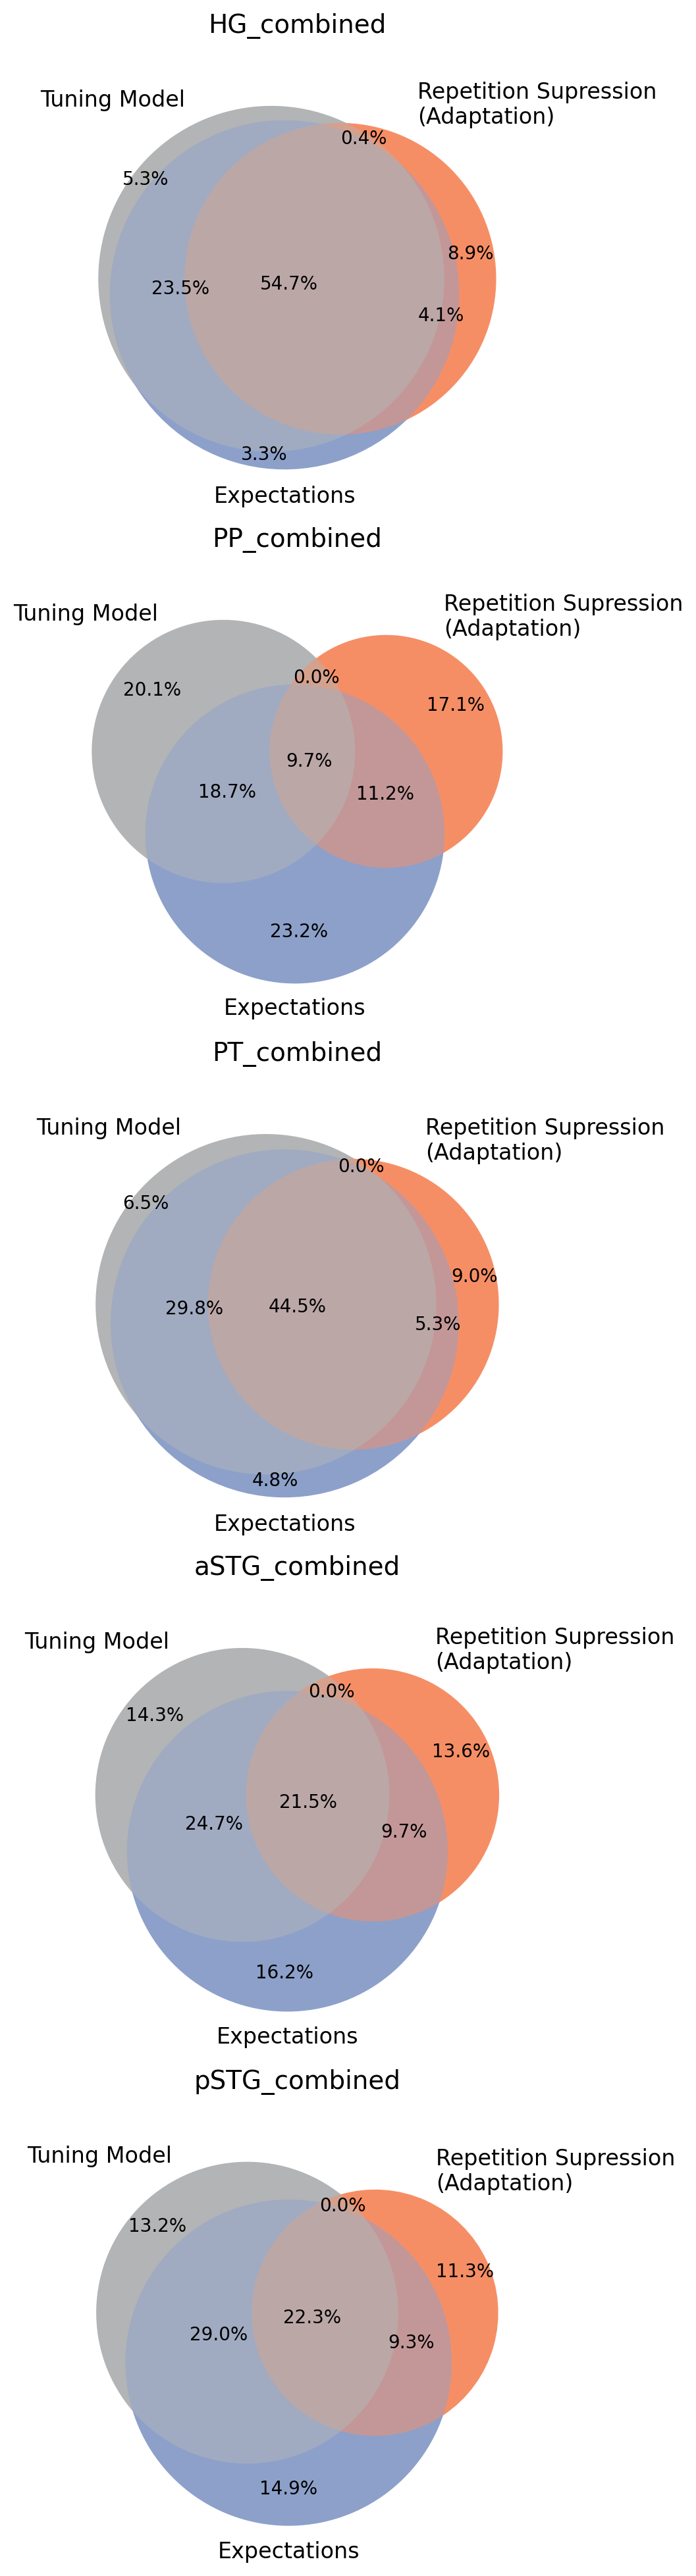

In [222]:
# # other parameters
# correct_r2s = False
# cv = False
# cv = True

# scores_fn = 'ANTS_scores'

scores_fn = 'ANTS_scores_pw_uw_er_lwo_tempsmooth' # 'scores_prec', 'IdealObserver_scores_pres_tempsmooth', 'IdealObserver_scores_pres'
corrected_fn = 'uncorrected' # 'uncorrected'
cv_fn = 'cv(median)' #'cv(median)' # 'non-cv'
threshold_p = 0.05
topnr = 200
handle_negatives = 'aubuc_remove'

# # get filename for r2s
# if correct_r2s: corrected_fn = 'corrected'
# else: corrected_fn = 'uncorrected'

# # get filename for cv
# if cv: cv_fn = 'cv'
# else: cv_fn = 'noncv'
    
# load 
average_df = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle')) 
# average_df = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{corrected_fn}_{cv_fn}(top{topnr}).pickle')) 

average_df_temp = average_df.loc[average_df['layer'] == 'combined']
average_df_temp = average_df_temp.loc[average_df_temp['roi'].str.contains('combined')]

# Create a figure with subplots in one row
fig, axes = plt.subplots(len(average_df_temp['roi'].unique()), 1, 
                         figsize=(5, 5 *  len(average_df_temp['roi'].unique())),
                        dpi=200)


for a, roi in enumerate(average_df_temp['roi'].unique()):
    set3 = average_df_temp.loc[average_df_temp['roi'] == roi].drop(['pp', 'roi', 'layer'], axis=1)
    set3 = tuple(set3[col].values for col in set3.columns)

    # Plot the results in a Venn diagram on the corresponding subplot
    ax = axes[a]  # Select the subplot
    fig = varpar.plot_3way_varpartven(set3,
                                      labels=['Tuning Model',
                                               'Repetition Supression\n(Adaptation)',
                                               'Expectations'],
                                      avgfun=_clipped_mean, # np.mean,
                                      alpha=1,
                                      ax=ax)  # Pass the subplot axis to the plotting function

    # Adjust labels based on negatives
#     fig = _check_negatives(fig, threshold=0)
    fig = _get_cumperc_venn3(fig)
    
    # Set the title of the subplot
    ax.set_title(f'{roi}\n', fontsize=14)

    varpar.pimpcollors_venn3(fig)  # base - pred
                        

#### Sanity check 2

Next we can plot the group average `Venn diagrams` per roi per layer

In [6]:
scores_fn = 'ANTS_scores_pw_uw_lwo_tempsmooth' # 'scores_prec', 'IdealObserver_scores_pres_tempsmooth', 'IdealObserver_scores_pres'
# scores_fn = 'ANTS_IdealObserver_scores_pw_uw_tempsmooth'
corrected_fn = 'uncorrected' # 'uncorrected'
cv_fn = 'cv(median)' #'cv(median)' #'cv(median)' # 'noncv'
handle_negatives = 'aubuc_remove'
threshold_p = 0.05

# pwuw, pw, _

In [7]:
def _clipped_mean(x):
    """clip negative means out, for visuallization"""
    return max(np.mean(x), 0)

def _check_negatives(fig, threshold=0):
    """
    Adjust the subset labels of a Venn diagram based on a threshold.
    
    Parameters:
    - fig: The Venn diagram figure.
    - threshold: The cutoff value below which labels will be hidden (default: 0).
    
    Returns:
    - Updated figure.
    """
    # Iterate over the subsets in the Venn diagram
    for subset in fig.subset_labels:
        if subset is not None:  # Only adjust existing labels
            try:
                value = float(subset.get_text())
                # Hide the label if the value is below the threshold
                if value < threshold:
                    value = np.abs(value)
                    subset.set_text(value)
            except ValueError:
                pass  # Skip if the label cannot be converted to float

    return fig

def _get_cumperc_venn3(fig, zeronegative=True):
    """get cummalative percentage for venn 3, apply to new fig"""

    # set combinations
    combs = ['100', '010', '001', '110', '101', '011', '111']
    combs = [vid for vid in combs if fig.get_label_by_id(vid) and fig.get_label_by_id(vid).get_text()]

    # set dictionary
    setdict = {comb : float(fig.get_label_by_id(comb).get_text()) for comb in combs}

    # get total
    total = np.sum(list(setdict.values()))

    # apply to figure
    for comb in combs:
        
        # deal with negatives
        if zeronegative: 
            if setdict[comb] < 0: setdict[comb] = 0
        fig.get_label_by_id(comb).set_text(f"{setdict[comb] * 100 / total:.1f}%")
        
    return fig

In [582]:
average_df = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle')) 
# average_df = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{corrected_fn}_{cv_fn}(top{topnr})-binned.pickle')) 


average_df_temp = average_df.loc[average_df['roi'].str.contains('combined')]
layers = ['Layer 1', 'Layer 2', 'Layer 3']
layernames = ['Deep', 'Middle', 'Superficial']

# Create a figure with subplots in one row
fig, axes = plt.subplots(len(average_df_temp['roi'].unique()), len(layers), 
                         figsize=(4.5 * len(layers), 4.5 *  len(average_df_temp['roi'].unique())),
                         dpi=600)


for a, roi in enumerate(average_df_temp['roi'].unique()):
    
    for l, lyr in enumerate(layers):
    
        # get correct layers and roi data
        set3 = average_df_temp.loc[(average_df_temp['roi'] == roi) &
                                   (average_df_temp['layer'] == lyr)].drop(['pp', 'roi', 'layer'], axis=1)
        set3 = tuple(set3[col].values for col in set3.columns)

        # Plot the results in a Venn diagram on the corresponding subplot
        ax = axes[a, l]  # Select the subplot
        try:
            fig = varpar.plot_3way_varpartven(set3,
                                              labels=['','',''],   #['Tuning Model',
                                                                  #'Repetition Supression\n(Adaptation)',
                                                                  #'Expectations'],
                                              avgfun=_clipped_mean, #np.mean
                                              alpha=1,
                                              ax=ax,
                                              formatround=3)  # Pass the subplot axis to the plotting function
            varpar.pimpcollors_venn3(fig)  # base - pred
        
            # Adjust labels based on negatives
            fig = _check_negatives(fig, threshold=0)
            fig = _get_cumperc_venn3(fig)
        
            # Set the title of the subplot
            ax.set_title(f'{roi} ({layernames[l]})\n', fontsize=14)
        except: pass

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()
                        

110not present
111not present
110not present
111not present
110not present
110not present
111not present
110not present


/home/jorvhar/miniconda3/envs/predlis/lib/python3.8/site-packages/matplotlib_venn/_venn3.py:117: UserWarning: Bad circle positioning
  warnings.warn("Bad circle positioning")


In [154]:
def analyze_bootstrap_effects(df, layer_pattern, roi_pattern, col_oi, pop_mean=0, tail='2s', n_boots=10e4, seed=123):
    """
    Filters a preloaded dataframe by layer and roi patterns, then computes the mean and bootstrapped
    one-sample t-test p-value for specified columns of interest.

    Parameters
    ----------
    df : pd.DataFrame
        The preloaded dataframe.
    layer_pattern : str
        Substring or regex pattern to match 'layer' column.
    roi_pattern : str
        Substring or regex pattern to match 'roi' column.
    col_oi : list of str
        List of column names to analyze.
    pop_mean : float
        The population mean to test against (default = 0).
    tail : str
        Tail for the test: '2s' (two-sided), 'l' (left), 'r' (right).
    n_boots : int
        Number of bootstrap samples.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    results : pd.DataFrame
        DataFrame with columns: ['column', 'mean', 'pval'] for each tested effect.
    """

    # Filter the dataframe
    df_sel = df[df['layer'].str.contains(layer_pattern) & df['roi'].str.contains(roi_pattern)]

    # Run the analysis
    results = []
    for col in col_oi:
        if col not in df_sel.columns:
            continue
        values = df_sel[col].dropna().values
        if len(values) == 0:
            continue
        mean_val = values.mean()
        pval = stats.bootstrap_t_onesample(values, pop_mean=pop_mean, tail=tail, n_boots=n_boots, seed=seed)
        results.append({'column': col, 'mean': mean_val, 'pval': pval})

    return pd.DataFrame(results)

## Statistics on ROI and layer level

### a. `roi` level

In [247]:
## QUICKLY DO STATITISCAL TESTS

# fetch data
scores_fn = 'ANTS_scores_pw_uw_er_lwo_tempsmooth' # 'scores_prec', 'IdealObserver_scores_pres_tempsmooth', 'IdealObserver_scores_pres'
average_df = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle')) 

print(f'loading: R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle')

# layer pattern
lp = 'combined'
# roi pattern
rp ='PT_combined'

# Columns of interest
col_oi = ['base', 'adaptation', 'prediction', 'base_u_adaptation',
           'base_u_prediction', 'adaptation_u_prediction',
           'base_u_adaptation_u_prediction', 'base*', 'adaptation*', 'prediction*',
           'base_n_adaptation*', 'base_n_prediction*', 'adaptation_n_prediction*',
           'base_n_adaptation_n_prediction',]
pdict = {cl : [] for cl in col_oi}

for rp in ['HG_combined', 'PP_combined', 'PT_combined', 'aSTG_combined', 'pSTG_combined']:

    print(f'\n--{rp}--')
    results_df = analyze_bootstrap_effects(
        df=average_df,
        layer_pattern=lp,
        roi_pattern=rp,
        col_oi=col_oi,
        pop_mean=0,
        tail='r',
        n_boots=1e5,
    )
    # add bonferoni corrected
    results_df['pbonf'] = results_df['pval'] * 5

    for cl in col_oi:
        pdict[cl].append(results_df.loc[results_df['column'] == cl, 'pval'].values[0])
    
    print(results_df.to_string(index=False, float_format="%.4g"))
    
## fdr corrected 
print('FDR CORRECTED STATS')

for coloi in ['base*', 'adaptation*', 'prediction*', 
              'base_n_adaptation*', 'base_n_prediction*', 'adaptation_n_prediction*']:

    pvals = pdict[coloi]

    reject_fdr, pvals_fdr, _, _ = statsmodels.stats.multitest.multipletests(pvals, alpha=0.05, method='fdr_bh')
    reject, pvals_bonf, _, _ = statsmodels.stats.multitest.multipletests(pvals, alpha=0.05, method='bonferroni')

    print(f'\nPartition: {coloi}')
    for idx, rp in enumerate(['HG_combined', 'PP_combined', 'PT_combined', 'aSTG_combined', 'pSTG_combined']):
        print(f'--{rp}--')
#         print(f'\t p(uncorreced):{pvals[idx]:.4f} \t p(fdr):{pvals_fdr[idx]:.4f}\t p(bonf):{pvals_bonf[idx]:.4f}')
        print(f'\t p(uncorreced):{pvals[idx]:.4f} \t p(fdr):{pvals_fdr[idx]:.1e} - sig={reject_fdr[idx]}')

loading: R2S_ANTS_scores_pw_uw_er_lwo_tempsmooth_aubuc_remove_uncorrected_cv(median)(p5e-02)-binned.pickle

--HG_combined--
                        column      mean    pval   pbonf
                          base  0.005728   3e-05 0.00015
                    adaptation  0.004646   4e-05  0.0002
                    prediction  0.005844   2e-05  0.0001
             base_u_adaptation   0.00661       0       0
             base_u_prediction   0.00623   2e-05  0.0001
       adaptation_u_prediction  0.006476   3e-05 0.00015
base_u_adaptation_u_prediction  0.006836       0       0
                         base* 0.0003598 0.02398  0.1199
                   adaptation* 0.0006052 0.00014  0.0007
                   prediction* 0.0002258  0.1092  0.5461
            base_n_adaptation*  2.71e-05  0.4363   2.182
            base_n_prediction*  0.001604 0.00056  0.0028
      adaptation_n_prediction* 0.0002766 0.00145 0.00725
base_n_adaptation_n_prediction  0.003737   7e-05 0.00035

--PP_combined--
    

### b. Layer level

In [110]:
## LAYER EFFECTS

## QUICKLY DO STATITISCAL TESTS

# fetch data
average_df = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle')) 

# Layers and ROIs to loop over
layer_patterns = ['Layer 1', 'Layer 2', 'Layer 3']
roi_patterns = ['HG_combined', 'PP_combined', 'PT_combined', 'aSTG_combined', 'pSTG_combined']

# Columns of interest
col_oi = ['base', 'adaptation', 'prediction', 'base_u_adaptation',
           'base_u_prediction', 'adaptation_u_prediction',
           'base_u_adaptation_u_prediction', 'base*', 'adaptation*', 'prediction*',
           'base_n_adaptation*', 'base_n_prediction*', 'adaptation_n_prediction*',
           'base_n_adaptation_n_prediction',]

for rp in roi_patterns:

    # set layer dictionary
    l_dict = {}
    
    for lp in layer_patterns:

        results_df = analyze_bootstrap_effects(
            df=average_df,
            layer_pattern=lp,
            roi_pattern=rp,
            col_oi=col_oi,
            pop_mean=0,
            tail='r',
            n_boots=1e4,
        )
        
        # save in dict
        for col in ['mean', 'pval']:
            l_dict[f'{col}({lp})'] = results_df[col]

    # also add the colunn name
    l_dict_df = pd.DataFrame({**{'column':results_df['column']}, **l_dict})
    
    print(f'\n -- ROI {rp} --')
    print(l_dict_df.to_string(index=False, float_format="%.4g"))


 -- ROI HG_combined --
                        column  mean(Layer 1)  pval(Layer 1)  mean(Layer 2)  pval(Layer 2)  mean(Layer 3)  pval(Layer 3)
                          base       0.003441              0       0.005935              0       0.007928              0
                    adaptation       0.002481              0       0.004703              0       0.006688              0
                    prediction       0.003833              0       0.005155              0       0.006816         0.0001
             base_u_adaptation       0.004415              0       0.006724              0       0.008692              0
             base_u_prediction        0.00451              0       0.005873              0        0.00772              0
       adaptation_u_prediction        0.00433              0       0.005914              0         0.0078              0
base_u_adaptation_u_prediction       0.004857              0       0.006215              0       0.008108              0
        

In [255]:
## FDR- LAYER RESULTS

# 1: deep
# 2: middle
# 3: superficial

# set rois
rois = ['HG_combined', 'PP_combined', 'PT_combined', 'aSTG_combined', 'pSTG_combined']
ttest_pairs = [['Layer 1', 'Layer 2'],
               ['Layer 2', 'Layer 3'],
               ['Layer 1', 'Layer 3']]
# Columns of interest
col_oi = ['base', 'adaptation', 'prediction', 'base_u_adaptation_u_prediction', 
          'base*', 'adaptation*', 'prediction*']
col_oi = ['base*', 'adaptation*', 'prediction*']
col_oi = ['base*', 'adaptation*', 'prediction*', 
          'base_n_adaptation*', 'base_n_prediction*', 'adaptation_n_prediction*',
          'base_n_adaptation_n_prediction']

# loading values
scores_fn = 'ANTS_scores_pw_uw_er_lwo_tempsmooth' 
corrected_fn = 'uncorrected'
cv_fn = 'cv(median)' 
threshold_p = 0.05

print(f'file: R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle')

# initiate pdict
pdict = {}
meandict = {}

# loop over areas
for area in rois:

    print(f'\n--{area}--')
    pdict[area] = {}
    meandict[area] = {}
    
    # load r2s
    average_df_temp = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle'))

    # get roi df
    layers = ['Layer 1', 'Layer 2', 'Layer 3']
    filtered_df = average_df_temp.loc[(average_df_temp['roi'] == area) & (average_df_temp['layer'].isin(layers))]

    # loop over columns of interest
    for c in col_oi:
    
        print(f'{c}')
        pdict[area][c] = []
        meandict[area][c] = []
    
        # loop over pairings
        for pair in ttest_pairs:

            # sellect layer mapping
            df1 = filtered_df.loc[filtered_df['layer'] == pair[0]]
            df2 = filtered_df.loc[filtered_df['layer'] == pair[1]]

            # get diffs
            diff = df1[c].to_numpy() - df2[c].to_numpy()
            meanval = np.mean(diff)
            pval = stats.bootstrap_t_onesample(diff, n_boots=1e5)
            pdict[area][c].append(pval)
            meandict[area][c].append(meanval)
            
            print(f'{pair[0]} - {pair[1]}\t - mean={meanval:.2e}, p={pval}, p_bonf={pval*15}')
            
## fdr corrected
print('FDR-CORRECTED')

import statsmodels

# add layer names
layernames = {'Layer 1' : 'D',
              'Layer 2' : 'M',
              'Layer 3' : 'S'}
roinames = {'HG_combined' : "Heschl's gyrus", 
            'PP_combined' : "Planum polare", 
            'PT_combined' : "Planum temporale", 
            'aSTG_combined' : "anterior STG", 
            'pSTG_combined' : "posterior STG"}
coinames = {'base*' : 'Tuning',
            'adaptation*' : 'Repetition Suppression',
            'prediction*' : 'Expectation',
            'base_n_adaptation*' : 'Tuning ∩ Repetition Suppression',
            'base_n_prediction*' : 'Tuning ∩ Expectation',
            'adaptation_n_prediction*' : 'Repetition Suppression ∩ Expectation',
            'base_u_adaptation_u_prediction' : 'Tuning ∩ Repetition Suppression ∩ Expectation'}

for coloi in ['base*', 'adaptation*', 'prediction*', 
              'base_n_adaptation*', 'base_n_prediction*', 'adaptation_n_prediction*',
              'base_n_adaptation_n_prediction']:

    pvals = [val for area in pdict.keys() for val in pdict[area][coloi]]
    meanvals = [val for area in meandict.keys() for val in meandict[area][coloi]]

    reject_fdr, pvals_fdr, _, _ = statsmodels.stats.multitest.multipletests(pvals, alpha=0.05, method='fdr_bh')
    reject, pvals_bonf, _, _ = statsmodels.stats.multitest.multipletests(pvals, alpha=0.05, method='bonferroni')

    print(f' {coinames[coloi]}')
    idx = 0
    for area in pdict.keys():
        print(f'--{roinames[area]}--')
        for pair in ttest_pairs:
#             print(f'{pair[0]} - {pair[1]}\t p(uncorreced):{pvals[idx]:.4f} \t p(fdr):{pvals_fdr[idx]:.4f}\t p(bonf):{pvals_bonf[idx]:.4f}')
            print(f'{layernames[pair[0]]} - {layernames[pair[1]]}\t  Mean:{meanvals[idx]:.2e} \t p(fdr):{pvals_fdr[idx]:.1e} sig={reject_fdr[idx]}')
            idx += 1

file: R2S_ANTS_scores_pw_uw_er_lwo_tempsmooth_aubuc_remove_uncorrected_cv(median)(p5e-02)-binned.pickle

--HG_combined--
base*
Layer 1 - Layer 2	 - mean=2.66e-04, p=0.12606, p_bonf=1.8909
Layer 2 - Layer 3	 - mean=1.87e-04, p=0.27526, p_bonf=4.1289
Layer 1 - Layer 3	 - mean=4.54e-04, p=0.05324, p_bonf=0.7986000000000001
adaptation*
Layer 1 - Layer 2	 - mean=-7.37e-05, p=0.6206, p_bonf=9.309000000000001
Layer 2 - Layer 3	 - mean=-3.21e-05, p=0.76888, p_bonf=11.5332
Layer 1 - Layer 3	 - mean=-1.06e-04, p=0.51258, p_bonf=7.688700000000001
prediction*
Layer 1 - Layer 2	 - mean=7.91e-04, p=0.00016, p_bonf=0.0024000000000000002
Layer 2 - Layer 3	 - mean=1.33e-04, p=0.52602, p_bonf=7.890300000000001
Layer 1 - Layer 3	 - mean=9.23e-04, p=0.00286, p_bonf=0.0429
base_n_adaptation*
Layer 1 - Layer 2	 - mean=4.76e-05, p=0.796, p_bonf=11.940000000000001
Layer 2 - Layer 3	 - mean=-1.82e-04, p=0.09672, p_bonf=1.4508
Layer 1 - Layer 3	 - mean=-1.34e-04, p=0.52316, p_bonf=7.8473999999999995
base_n_pred

## 5. Visualization: Per `component`

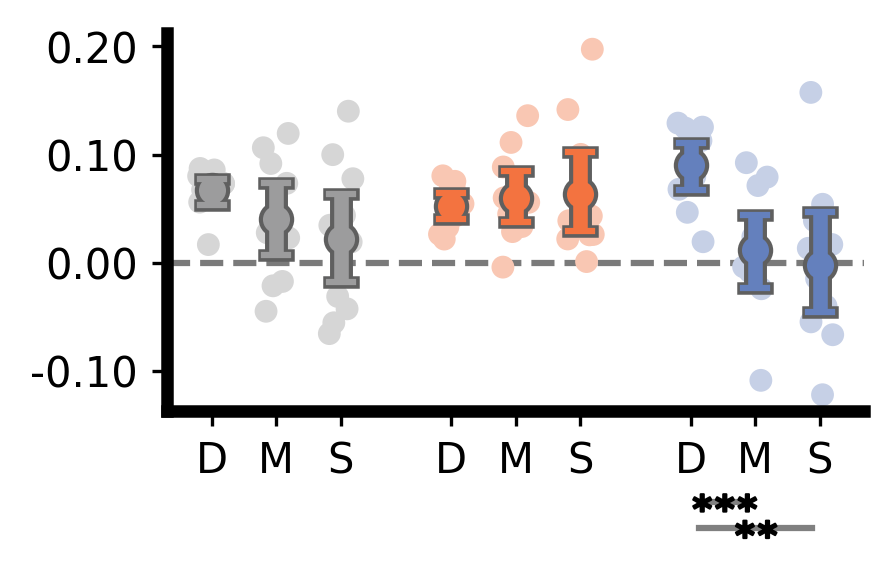

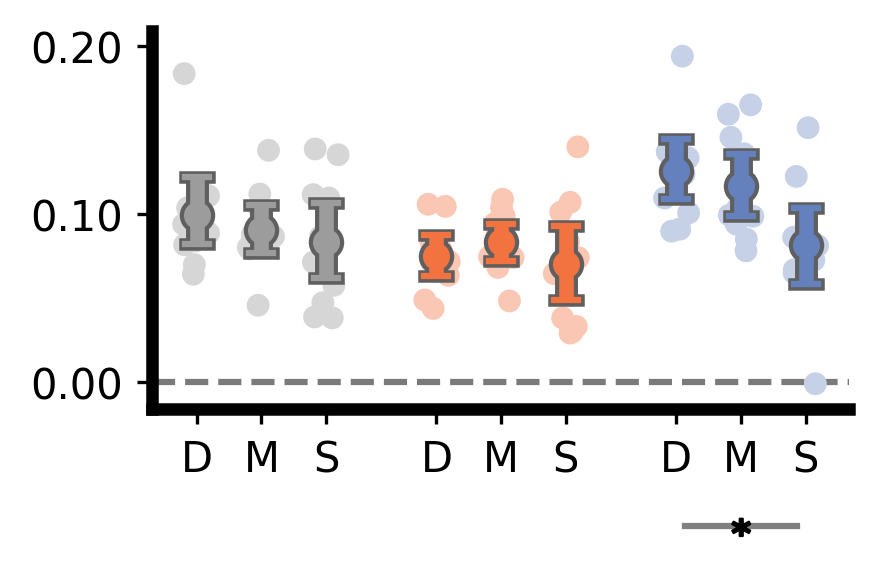

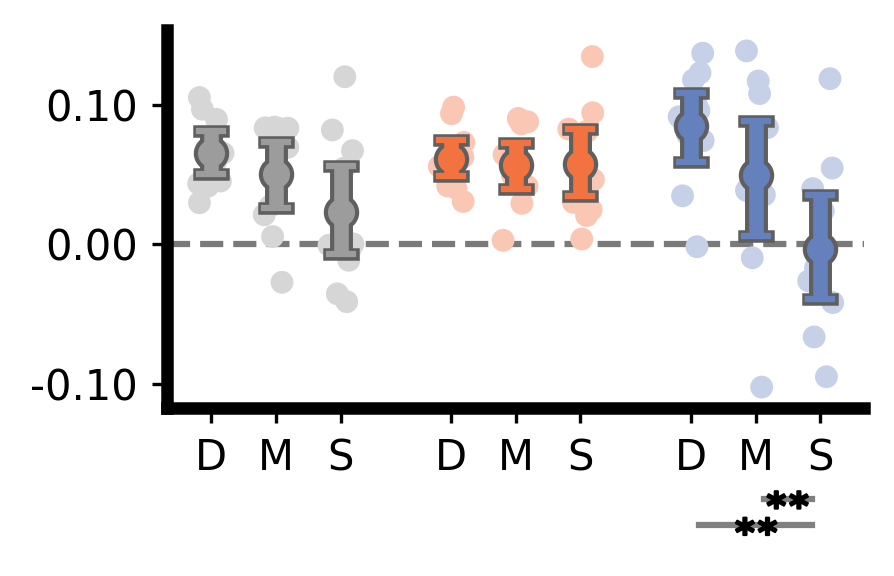

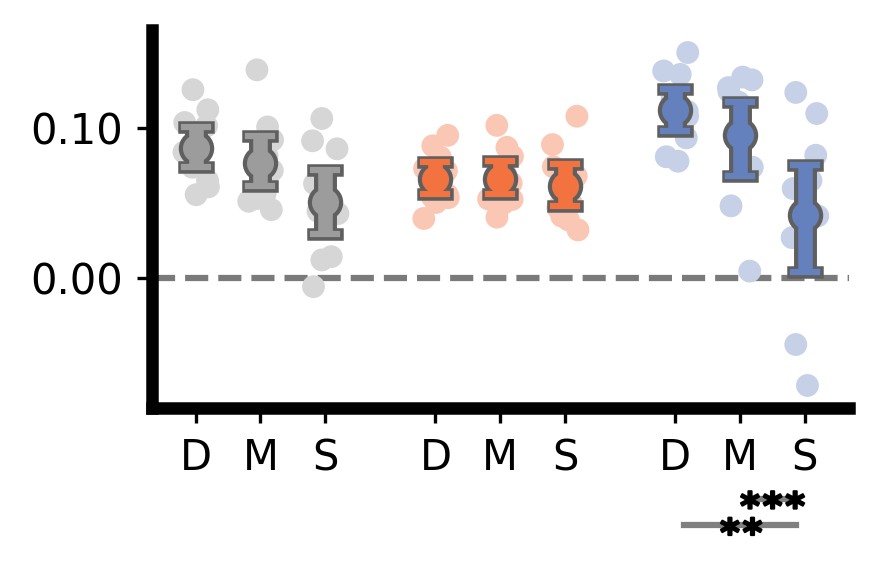

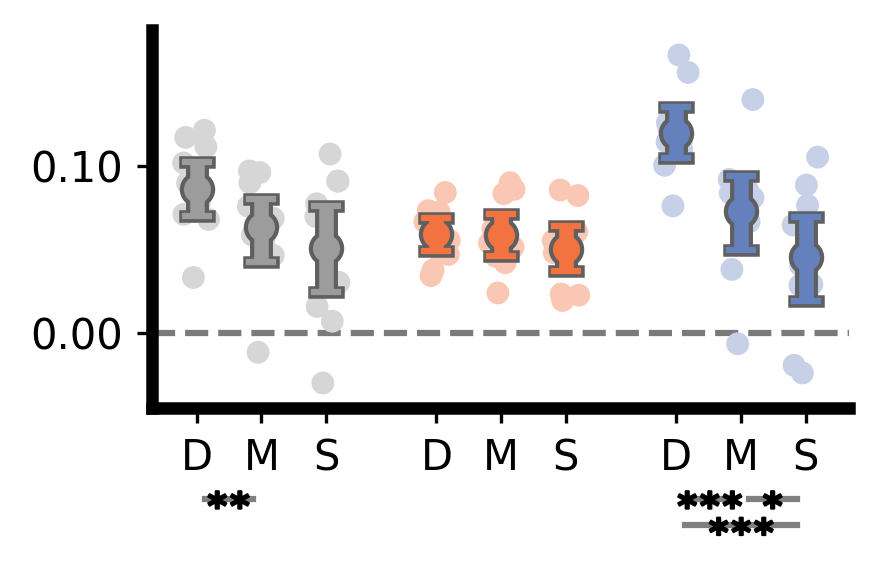

In [366]:
## NEW VERSION BUT NOW PER LAYER, SO D, M, S

def get_star_line(stars, position, sy1='∗', sy2='⋅'):
    star_counts = [s.count(sy1) + s.count(sy2) for s in stars]
    line_parts = []
    for i, count in enumerate(star_counts):
        if i == position:
            original_stars = ''.join(c for c in stars[i] if c in f'{sy1}{sy2}')
            line_parts.append(original_stars)
        else:
            line_parts.append(' ' * count)
    # Now join without adding any extra spaces
    return ' '.join(line_parts)

def get_symbol_line(stars, symbol='-', sy1='∗', sy2='⋅'):
    star_counts = [s.count(sy1) + s.count(sy2) for s in stars]
    if len(stars) <= 1:
        return ''
    return f'{symbol}'.join(' ' * i for i in star_counts)



import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from os.path import join
from matplotlib.transforms import blended_transform_factory
import matplotlib.patheffects as path_effects

def smart_jitter(values, center=0, x_range=0.15, min_dist=1.5):
    """Jitter points horizontally around a center while avoiding overlap in both axes."""
    positions = []
    np.random.seed(42)
    y_spacing = np.std(values) / 100  # small fudge factor
    for y in values:
        tries = 0
        while True:
            x = np.random.uniform(center - x_range, center + x_range)
            too_close = False
            for (x0, y0) in positions:
                if np.sqrt((x - x0)**2 + ((y - y0)/min_dist)**2) < 0.03:
                    too_close = True
                    break
            if not too_close or tries > 100:
                positions.append((x, y))
                break
            tries += 1
    x_jittered, y_jittered = zip(*positions)
    return np.array(x_jittered)

scores_fn = 'ANTS_scores_pw_uw_er_lwo_tempsmooth' 
corrected_fn = 'uncorrected'
cv_fn = 'cv(median)' 
threshold_p = 0.05

# outline
outline = True
show_ylabel = False

# set capwith
errwidth = 0.1  # Adjust this value to change cap width

# sig values # †
# * : p<0.05
# ** : p<0.01
# *** : p<0.001
# † : p_uncorrect<0.05
sigs = {}
## without error
# sigs['HG_combined'] = {'sig_12': ['prediction∗∗∗'], 'sig_23': [], 'sig_13': ['prediction∗']}
# sigs['PP_combined'] = {'sig_12': [], 'sig_23': ['prediction⋅'], 'sig_13': ['prediction⋅']}
# sigs['PT_combined'] = {'sig_12': ['prediction⋅'], 'sig_23': ['prediction⋅'], 'sig_13': ['prediction∗']}
# sigs['aSTG_combined'] = {'sig_12': ['base⋅'], 'sig_23': ['prediction⋅'], 'sig_13': ['prediction∗']}
# sigs['pSTG_combined'] = {'sig_12': ['base⋅', 'prediction∗'], 'sig_23': ['prediction∗'], 'sig_13': ['prediction∗∗']}

## with error
# sigs['HG_combined'] = {'sig_12': ['prediction∗∗'], 'sig_23': [], 'sig_13': ['prediction∗']}
# sigs['PP_combined'] = {'sig_12': [], 'sig_23': [], 'sig_13': ['prediction⋅']}
# sigs['PT_combined'] = {'sig_12': ['prediction⋅'], 'sig_23': ['base⋅', 'prediction⋅'], 'sig_13': ['prediction⋅']}
# sigs['aSTG_combined'] = {'sig_12': [], 'sig_23': ['base⋅', 'prediction∗∗'], 'sig_13': ['base⋅', 'prediction∗']}
# sigs['pSTG_combined'] = {'sig_12': ['base∗∗', 'prediction∗∗'], 'sig_23': ['prediction⋅'], 'sig_13': ['base⋅', 'prediction∗∗']}

## FDR
sigs['HG_combined'] = {'sig_12': ['prediction∗∗∗'], 'sig_23': [], 'sig_13': ['prediction∗∗']}
sigs['PP_combined'] = {'sig_12': [], 'sig_23': [], 'sig_13': ['prediction∗']}
sigs['PT_combined'] = {'sig_12': [], 'sig_23': ['prediction∗∗'], 'sig_13': ['prediction∗∗']}
sigs['aSTG_combined'] = {'sig_12': [], 'sig_23': ['prediction∗∗∗'], 'sig_13': ['prediction∗∗']}
sigs['pSTG_combined'] = {'sig_12': ['base∗∗', 'prediction∗∗∗'], 'sig_23': ['prediction∗'], 'sig_13': ['prediction∗∗∗']}


sigs_colors = {'base∗': '#b3b4b5',
               'adaptation∗': '#f68e65',
               'prediction∗': '#8ca0ca',
               'base∗∗': '#b3b4b5',
               'adaptation∗∗': '#f68e65',
               'prediction∗∗': '#8ca0ca',
               'base∗∗∗': '#b3b4b5',
               'adaptation∗∗∗': '#f68e65',
               'prediction∗∗∗': '#8ca0ca',               
               'base†': '#b3b4b5',
               'adaptation†': '#f68e65',
               'prediction†': '#8ca0ca',               
               'base⋅': '#b3b4b5',
               'adaptation⋅': '#f68e65',
               'prediction⋅': '#8ca0ca'}
sigs_posx = {'sig_12': 0.455,
               'sig_23': 0.545,
               'sig_13': 0.5}
sigs_posy = {'sig_12': -0.2675,
               'sig_23': -0.2675,
               'sig_13': -0.3375}
sigs_posy = {'sig_12': -0.2475,
               'sig_23': -0.2475,
               'sig_13': -0.3175}

sigs_posx_clm = [-0.345, 0, 0.345]


# set rois
rois = ['HG_combined', 'PP_combined', 'PT_combined', 'aSTG_combined', 'pSTG_combined']
for area in rois:

    average_df_temp = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle'))

    layers = ['Layer 1', 'Layer 2', 'Layer 3']
    filtered_df = average_df_temp.loc[(average_df_temp['roi'] == area) & (average_df_temp['layer'].isin(layers))]

    plt.figure(figsize=(3, 2), dpi=300)

        # switch: factors on x-axis, layers grouped within each factor
    factors = ['Tuning Model', 'Repetition Suppresion', 'Expectations']
    columns = ['base*', 'adaptation*', 'prediction*']
    factor_colors = ['#9C9C9D', '#F37340', '#6480BD']  # darker versions: #98999A, #F3642B, #6580B8 # lighter 
    factor_colors_light = ['#D6D6D6', '#F9C7B3', '#C6D0E6']
    layers = ['Layer 1', 'Layer 2', 'Layer 3']
    layer_offsets = [-0.27, 0.0, 0.27]  # bar offsets within each factor
    layer_labels = ['Deep', 'Middle', 'Superficial']

    for f_idx, (col, factor, f_color) in enumerate(zip(columns, factors, factor_colors)):
        for l_idx, (layer, offset) in enumerate(zip(layers, layer_offsets)):
            layer_data = filtered_df.loc[filtered_df['layer'] == layer, col] * 100
            x_pos = f_idx + offset

            # scatter individual datapoints
            x_jitter = smart_jitter(layer_data.to_numpy(), center=x_pos, x_range=0.055, min_dist=2.0)
            plt.scatter(x_jitter, layer_data, s=30,
                        color=factor_colors_light[f_idx], edgecolors='none', alpha=1.0)

            # CI line
            ci_low, ci_high = stats.bootstrap_ci(layer_data.to_numpy())
            median_val = np.mean(layer_data)

            if outline:
                plt.plot(x_pos, median_val, 'o', color=f_color, markersize=7.5,
                         markeredgewidth=1.0, markeredgecolor='#5F5F5F', zorder=3)
                plt.plot([x_pos, x_pos], [ci_low, ci_high],
                         color='#5F5F5F', lw=5.5, zorder=2, solid_capstyle='butt')
                plt.plot([x_pos, x_pos], [ci_low, ci_high],
                         color=f_color, lw=3.5, zorder=3, solid_capstyle='butt')
                # caps
                for y_val in [ci_low, ci_high]:
                    plt.plot([x_pos - errwidth/2, x_pos + errwidth/2],
                             [y_val, y_val], color='#5F5F5F', lw=3, zorder=2)
                    plt.plot([x_pos - errwidth/2, x_pos + errwidth/2],
                             [y_val, y_val], color=f_color, lw=1.5, zorder=3)
            else:
                plt.plot(x_pos, median_val, 'o', color=f_color, markersize=7.5)
                plt.plot([x_pos, x_pos], [ci_low, ci_high],
                         color=f_color, lw=4.5, solid_capstyle='butt')
                for y_val in [ci_low, ci_high]:
                    plt.plot([x_pos - errwidth/2, x_pos + errwidth/2],
                             [y_val, y_val], color=f_color, lw=1.5)

    ax = plt.gca()
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(3)
    ax.spines['bottom'].set_linewidth(3)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

    tick_positions = []
    tick_labels = []
    for f_idx in range(len(factors)):
        for offset, lbl in zip(layer_offsets, ['D', 'M', 'S']):
            tick_positions.append(f_idx + offset)
            tick_labels.append(lbl)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=10)

    
    ylimmax = (np.max(filtered_df[columns]) * 100) + 0.015
    ylimmin = (np.min(filtered_df[columns]) * 100) - 0.015
    ax.set_ylim(ylimmin, ylimmax)

    # horizontal line at 0
    plt.axhline(0, linestyle='--', color='#7A7A7A', alpha=1, linewidth=1.5, zorder=0)

    for idx, label in enumerate(labels):
        plt.plot([], [], color=colors[idx], lw=4, label=label)
    

 # === Draw layer comparison lines below plot, outside data space ===

    # lookup sig values
    sig_lookup = sigs.get(area, {})

    # Get axis and figure transform to position below axis area
    trans = blended_transform_factory(ax.transData, ax.transAxes)

    y_pos_main = -0.24  # controls vertical position under the x-axis (play with this value)
    spacing = 0.07     # vertical spacing for non-overlapping long line
    x_spacing = 0.035

    # Comparison: Deep–Middle (0–1)
    if len(sig_lookup['sig_12']) > 0: # check if any sig
        
        # check all the columns
        for c_idx, c in enumerate(columns):
            if any(re.match(f'^{c}.*', item) for item in sig_lookup['sig_12']):
                ax.plot([layer_offsets[0]+c_idx+x_spacing, layer_offsets[1]+c_idx-x_spacing], [y_pos_main, y_pos_main], transform=trans, color='grey', lw=1.5, clip_on=False)

    # Comparison: Middle–Superficial (1–2)
    if len(sig_lookup['sig_23']) > 0: # check if any sig
        
        # check all the columns
        for c_idx, c in enumerate(columns):
            if any(re.match(f'^{c}.*', item) for item in sig_lookup['sig_23']):
                ax.plot([layer_offsets[1]+c_idx+x_spacing, layer_offsets[2]+c_idx-x_spacing], [y_pos_main, y_pos_main], transform=trans, color='grey', lw=1.5, clip_on=False)

    # Comparison: Deep–Superficial (0–2), offset slightly lower
    if len(sig_lookup['sig_13']) > 0: # check if any sig
        
        # check all the columns
        for c_idx, c in enumerate(columns):
            if any(re.match(f'^{c}.*', item) for item in sig_lookup['sig_13']):
                ax.plot([layer_offsets[0]+c_idx+x_spacing, layer_offsets[2]+c_idx-x_spacing], [y_pos_main - spacing, y_pos_main - spacing], transform=trans, color='grey', lw=1.5, clip_on=False)

    # Optional: extend figure bottom margin to make space
    plt.subplots_adjust(bottom=0.25)
    
    ## set significance marking
    for comp in ['sig_12', 'sig_23', 'sig_13']:
        stars = sig_lookup.get(comp, [])
        for st_idx, star in enumerate(stars):
            
            # dont combine stars, just present 1
            constructtxt = get_star_line([star], 0)
            
            # check all the columns
            for c_idx, c in enumerate(columns):
                # check if column is star
                if re.match(f"^{re.escape(c.rstrip('*'))}.*", star):
            
                    posx = sigs_posx[comp] + sigs_posx_clm[c_idx]
            
                    txt = ax.text(posx, sigs_posy[comp], constructtxt, horizontalalignment='center', verticalalignment='center', 
                                  transform=ax.transAxes, fontsize=9, fontweight='bold', color='black', fontname='monospace')
                    txt.set_path_effects([
                                    path_effects.Stroke(linewidth=0.5, foreground='black'),
                                    path_effects.Normal()
                                    ])

    # adjust labeling
    if show_ylabel:
        plt.ylabel('Cross-validated R² (%)', fontsize=10)
    else:
        ax.set_ylabel(None)
        ax.yaxis.set_label_coords(-0.1, 0.5)  # pushes invisible label space out, optional
        area = f'{area}_noYlabel'
    
    
    # save
    outname_base = join('visualisation', f'layerresults_{area}_outlined' if outline else f'layerresults_{area}')
    plt.savefig(f'{outname_base}_v2.svg', bbox_inches='tight', dpi=300)
    plt.savefig(f'{outname_base}_v2.pdf', bbox_inches='tight')
#     plt.savefig(f'{outname_base}_v2.jpg', bbox_inches='tight', dpi=300)
        
    plt.show()


## 6. Looking at common portion of variance

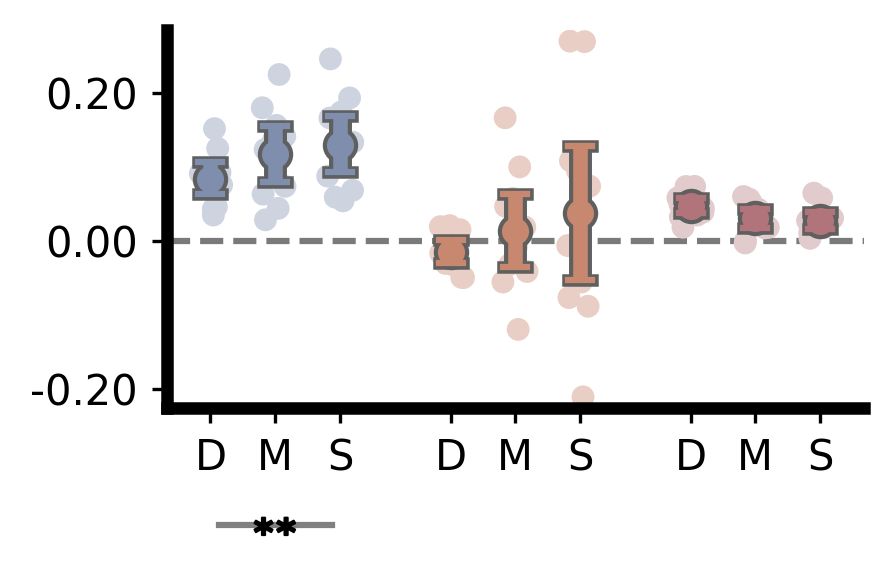

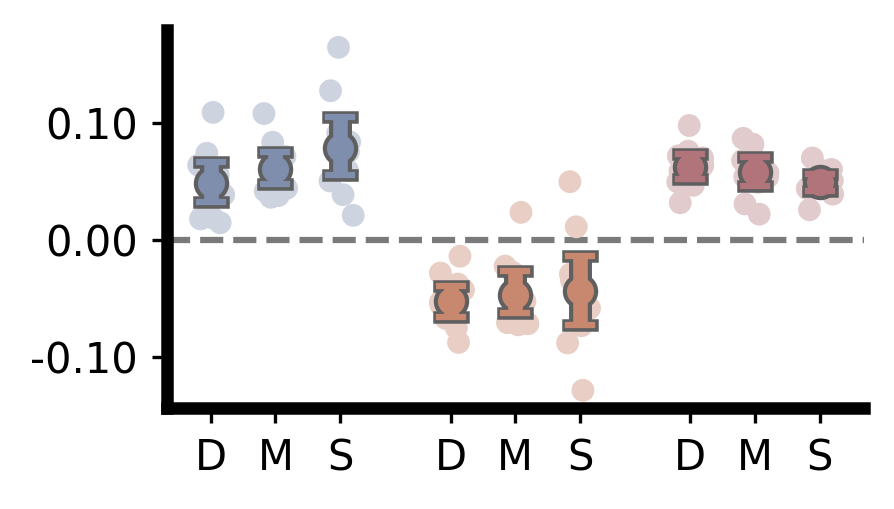

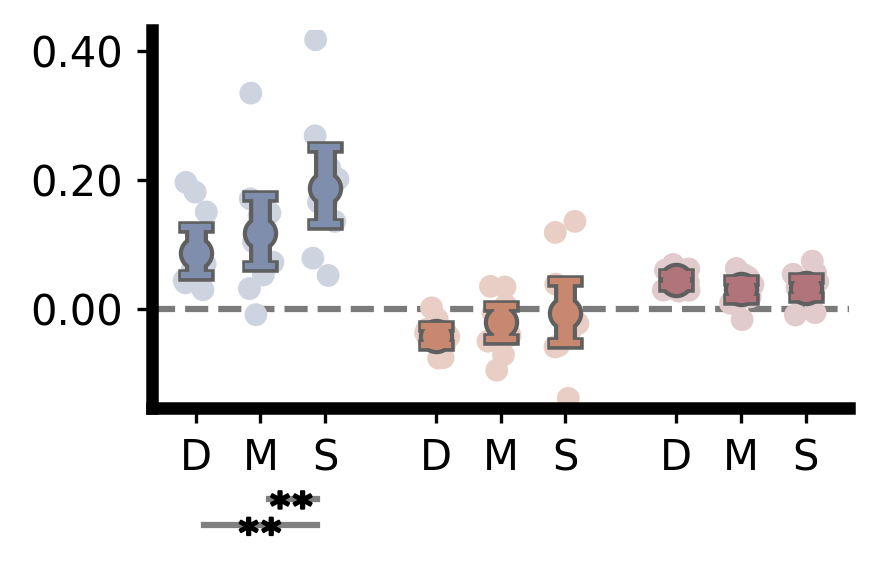

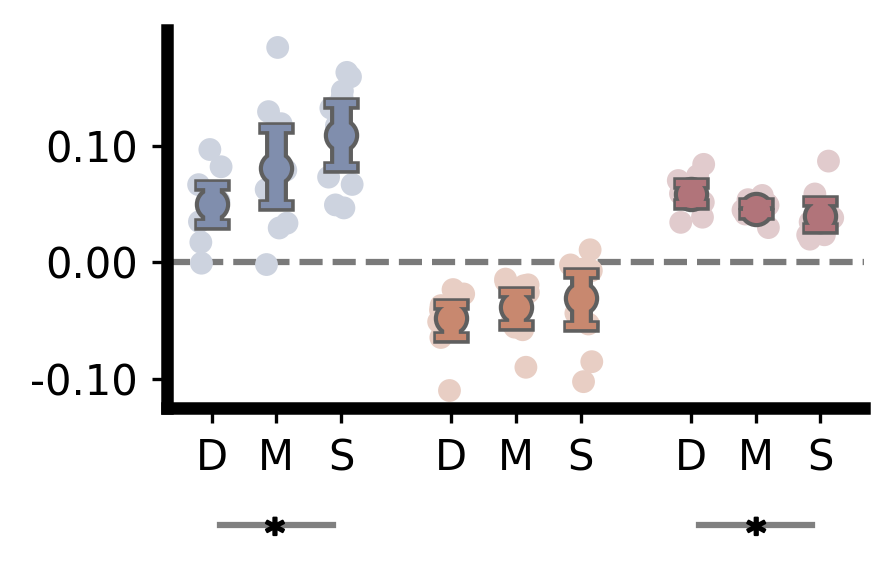

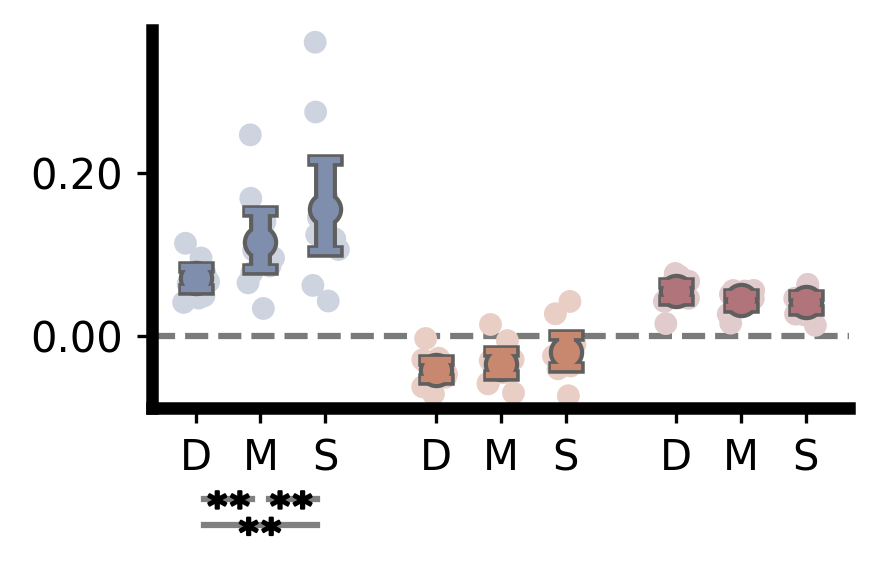

In [364]:
## YET AGAIN DO THE SAME REARANGING HERE - NOW GROUPED PER COLUMN

def get_star_line(stars, position, sy1='∗', sy2='⋅'):
    star_counts = [s.count(sy1) + s.count(sy2) for s in stars]
    line_parts = []
    for i, count in enumerate(star_counts):
        if i == position:
            original_stars = ''.join(c for c in stars[i] if c in f'{sy1}{sy2}')
            line_parts.append(original_stars)
        else:
            line_parts.append(' ' * count)
    # Now join without adding any extra spaces
    return ' '.join(line_parts)

def get_symbol_line(stars, symbol='-', sy1='∗', sy2='⋅'):
    star_counts = [s.count(sy1) + s.count(sy2) for s in stars]
    if len(stars) <= 1:
        return ''
    return f'{symbol}'.join(' ' * i for i in star_counts)


# sig values # †
# * : p<0.05
# ** : p<0.01
# *** : p<0.001
# † : p_uncorrect<0.05

sigs = {}
# ## without errors
# sigs['HG_combined'] = {'sig_12': ['base_n_prediction⋅'], 'sig_23': ['adaptation_n_prediction⋅'], 'sig_13': ['base_n_prediction⋅']}
# sigs['PP_combined'] = {'sig_12': [], 'sig_23': [], 'sig_13': ['base_n_prediction⋅', 'adaptation_n_prediction⋅']}
# sigs['PT_combined'] = {'sig_12': [], 'sig_23': ['base_n_prediction∗'], 'sig_13': ['base_n_prediction∗', 'adaptation_n_prediction⋅']}
# sigs['aSTG_combined'] = {'sig_12': ['adaptation_n_prediction⋅'], 'sig_23': [], 'sig_13': ['base_n_prediction⋅','adaptation_n_prediction⋅']}
# sigs['pSTG_combined'] = {'sig_12': ['base_n_prediction∗', 'adaptation_n_prediction⋅'], 'sig_23': ['base_n_prediction∗'], 'sig_13': ['base_n_prediction∗', 'adaptation_n_prediction⋅']}
# with errors
# sigs['HG_combined'] = {'sig_12': ['base_n_prediction⋅'], 'sig_23': [], 'sig_13': ['base_n_prediction∗']}
# sigs['PP_combined'] = {'sig_12': [], 'sig_23': [], 'sig_13': ['base_n_prediction⋅']}
# sigs['PT_combined'] = {'sig_12': ['adaptation_n_prediction⋅'], 'sig_23': ['base_n_prediction∗∗'], 'sig_13': ['base_n_prediction∗∗']}
# sigs['aSTG_combined'] = {'sig_12': ['adaptation_n_prediction⋅'], 'sig_23': ['base_n_prediction⋅','adaptation_n_prediction⋅'], 'sig_13': ['base_n_prediction⋅','adaptation_n_prediction∗']}
# sigs['pSTG_combined'] = {'sig_12': ['base_n_prediction∗∗', 'adaptation_n_prediction⋅'], 'sig_23': ['base_n_prediction∗'], 'sig_13': ['base_n_prediction∗∗']}

# FDR
sigs['HG_combined'] = {'sig_12': [], 'sig_23': [], 'sig_13': ['base_n_prediction∗∗']}
sigs['PP_combined'] = {'sig_12': [], 'sig_23': [], 'sig_13': []}
sigs['PT_combined'] = {'sig_12': [], 'sig_23': ['base_n_prediction∗∗'], 'sig_13': ['base_n_prediction∗∗']}
sigs['aSTG_combined'] = {'sig_12': [], 'sig_23': [], 'sig_13': ['base_n_prediction∗', 'adaptation_n_prediction∗']}
sigs['pSTG_combined'] = {'sig_12': ['base_n_prediction∗∗'], 'sig_23': ['base_n_prediction∗∗'], 'sig_13': ['base_n_prediction∗∗']}


sigs_colors = {'base_n_prediction∗': '#A0ABC1',
               'adaptation_n_prediction∗': '#C39798',
               'base_n_adaptation∗': '#D5A18D',
               'base_n_prediction∗∗': '#A0ABC1',
               'adaptation_n_prediction∗∗': '#C39798',
               'base_n_adaptation∗∗': '#D5A18D',
               'base_n_prediction∗∗∗': '#A0ABC1',
               'adaptation_n_prediction∗∗∗': '#C39798',
               'base_n_adaptation∗∗∗': '#D5A18D',               
               'base_n_prediction†': '#A0ABC1',
               'adaptation_n_prediction†': '#C39798',
               'base_n_adaptation†': '#D5A18D',               
               'base_n_prediction⋅': '#A0ABC1',
               'adaptation_n_prediction⋅': '#C39798',
               'base_n_adaptation⋅': '#D5A18D'}
sigs_posx = {'sig_12': 0.455,
               'sig_23': 0.545,
               'sig_13': 0.5}
sigs_posy = {'sig_12': -0.2675,
               'sig_23': -0.2675,
               'sig_13': -0.3375}
sigs_posy = {'sig_12': -0.2475,
               'sig_23': -0.2475,
               'sig_13': -0.3175}

sigs_posx_clm = [-0.345, 0, 0.345]

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from os.path import join
from matplotlib.transforms import blended_transform_factory
import matplotlib.patheffects as path_effects

def smart_jitter(values, center=0, x_range=0.15, min_dist=1.5):
    """Jitter points horizontally around a center while avoiding overlap in both axes."""
    np.random.seed(43)
    positions = []
    y_spacing = np.std(values) / 100  # small fudge factor
    for y in values:
        tries = 0
        while True:
            x = np.random.uniform(center - x_range, center + x_range)
            too_close = False
            for (x0, y0) in positions:
                if np.sqrt((x - x0)**2 + ((y - y0)/min_dist)**2) < 0.03:
                    too_close = True
                    break
            if not too_close or tries > 100:
                positions.append((x, y))
                break
            tries += 1
    x_jittered, y_jittered = zip(*positions)
    return np.array(x_jittered)

scores_fn = 'ANTS_scores_pw_uw_lwo_tempsmooth' 
corrected_fn = 'uncorrected'
cv_fn = 'cv(median)' 
threshold_p = 0.05

# outline
outline = True
show_ylabel = False

# set capwith
errwidth = 0.1  # Adjust this value to change cap width

# set rois
rois = ['HG_combined', 'PP_combined', 'PT_combined', 'aSTG_combined', 'pSTG_combined']
for area in rois:

    average_df_temp = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle'))

    layers = ['Layer 1', 'Layer 2', 'Layer 3']
    filtered_df = average_df_temp.loc[(average_df_temp['roi'] == area) & (average_df_temp['layer'].isin(layers))]

    plt.figure(figsize=(3, 2), dpi=300)

    factor_colors = ['#808EAD', '#C8886F', '#B1747A']
    factor_colors_light = ['#CDD3DF', '#E8CEC4', '#E1CBCD']
#     colors_light = ['#B7C4DD', '#E9B39E', '#D8A7A8'] 
    labels = ['Tuning Model', 'Repetition Suppresion', 'Expectations']
    columns = ['base_n_prediction*', 'base_n_adaptation*', 'adaptation_n_prediction*']
    layer_offsets = [-0.27, 0.0, 0.27]  # bar offsets within each factor

    for f_idx, (col, factor, f_color) in enumerate(zip(columns, factors, factor_colors)):
        for l_idx, (layer, offset) in enumerate(zip(layers, layer_offsets)):
            layer_data = filtered_df.loc[filtered_df['layer'] == layer, col] * 100
            x_pos = f_idx + offset

            # scatter individual datapoints
            x_jitter = smart_jitter(layer_data.to_numpy(), center=x_pos, x_range=0.055, min_dist=2.0)
            plt.scatter(x_jitter, layer_data, s=30,
                        color=factor_colors_light[f_idx], edgecolors='none', alpha=1.0)

            # CI line
            ci_low, ci_high = stats.bootstrap_ci(layer_data.to_numpy())
            median_val = np.mean(layer_data)

            if outline:
                plt.plot(x_pos, median_val, 'o', color=f_color, markersize=7.5,
                         markeredgewidth=1.0, markeredgecolor='#5F5F5F', zorder=3)
                plt.plot([x_pos, x_pos], [ci_low, ci_high],
                         color='#5F5F5F', lw=5.5, zorder=2, solid_capstyle='butt')
                plt.plot([x_pos, x_pos], [ci_low, ci_high],
                         color=f_color, lw=3.5, zorder=3, solid_capstyle='butt')
                # caps
                for y_val in [ci_low, ci_high]:
                    plt.plot([x_pos - errwidth/2, x_pos + errwidth/2],
                             [y_val, y_val], color='#5F5F5F', lw=3, zorder=2)
                    plt.plot([x_pos - errwidth/2, x_pos + errwidth/2],
                             [y_val, y_val], color=f_color, lw=1.5, zorder=3)
            else:
                plt.plot(x_pos, median_val, 'o', color=f_color, markersize=7.5)
                plt.plot([x_pos, x_pos], [ci_low, ci_high],
                         color=f_color, lw=4.5, solid_capstyle='butt')
                for y_val in [ci_low, ci_high]:
                    plt.plot([x_pos - errwidth/2, x_pos + errwidth/2],
                             [y_val, y_val], color=f_color, lw=1.5)

    ax = plt.gca()
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(3)
    ax.spines['bottom'].set_linewidth(3)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

    tick_positions = []
    tick_labels = []
    for f_idx in range(len(factors)):
        for offset, lbl in zip(layer_offsets, ['D', 'M', 'S']):
            tick_positions.append(f_idx + offset)
            tick_labels.append(lbl)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=10)

    
    ylimmax = (np.max(filtered_df[columns]) * 100) + 0.015
    ylimmin = (np.min(filtered_df[columns]) * 100) - 0.015
    ax.set_ylim(ylimmin, ylimmax)

    # horizontal line at 0
    plt.axhline(0, linestyle='--', color='#7A7A7A', alpha=1, linewidth=1.5, zorder=0)

    for idx, label in enumerate(labels):
        plt.plot([], [], color=colors[idx], lw=4, label=label)
    

 # === Draw layer comparison lines below plot, outside data space ===

    # lookup sig values
    sig_lookup = sigs.get(area, {})

    # Get axis and figure transform to position below axis area
    trans = blended_transform_factory(ax.transData, ax.transAxes)

    y_pos_main = -0.24  # controls vertical position under the x-axis (play with this value)
    spacing = 0.07     # vertical spacing for non-overlapping long line
    x_spacing = 0.035

    # Comparison: Deep–Middle (0–1)
    if len(sig_lookup['sig_12']) > 0: # check if any sig
        
        # check all the columns
        for c_idx, c in enumerate(columns):
            if any(re.match(f'^{c}.*', item) for item in sig_lookup['sig_12']):
                ax.plot([layer_offsets[0]+c_idx+x_spacing, layer_offsets[1]+c_idx-x_spacing], [y_pos_main, y_pos_main], transform=trans, color='grey', lw=1.5, clip_on=False)

    # Comparison: Middle–Superficial (1–2)
    if len(sig_lookup['sig_23']) > 0: # check if any sig
        
        # check all the columns
        for c_idx, c in enumerate(columns):
            if any(re.match(f'^{c}.*', item) for item in sig_lookup['sig_23']):
                ax.plot([layer_offsets[1]+c_idx+x_spacing, layer_offsets[2]+c_idx-x_spacing], [y_pos_main, y_pos_main], transform=trans, color='grey', lw=1.5, clip_on=False)

    # Comparison: Deep–Superficial (0–2), offset slightly lower
    if len(sig_lookup['sig_13']) > 0: # check if any sig
        
        # check all the columns
        for c_idx, c in enumerate(columns):
            if any(re.match(f'^{c}.*', item) for item in sig_lookup['sig_13']):
                ax.plot([layer_offsets[0]+c_idx+x_spacing, layer_offsets[2]+c_idx-x_spacing], [y_pos_main - spacing, y_pos_main - spacing], transform=trans, color='grey', lw=1.5, clip_on=False)

    # Optional: extend figure bottom margin to make space
    plt.subplots_adjust(bottom=0.25)
    
    ## set significance marking
    for comp in ['sig_12', 'sig_23', 'sig_13']:
        stars = sig_lookup.get(comp, [])
        for st_idx, star in enumerate(stars):
            
            # dont combine stars, just present 1
            constructtxt = get_star_line([star], 0)
            
            # check all the columns
            for c_idx, c in enumerate(columns):
                # check if column is star
                if re.match(f"^{re.escape(c.rstrip('*'))}.*", star):
            
                    posx = sigs_posx[comp] + sigs_posx_clm[c_idx]
            
                    txt = ax.text(posx, sigs_posy[comp], constructtxt, horizontalalignment='center', verticalalignment='center', 
                                  transform=ax.transAxes, fontsize=9, fontweight='bold', color='black', fontname='monospace')
                    txt.set_path_effects([
                                    path_effects.Stroke(linewidth=0.5, foreground='black'),
                                    path_effects.Normal()
                                    ])

    # adjust labeling
    if show_ylabel:
        plt.ylabel('Cross-validated R² (%)', fontsize=10)
    else:
        ax.set_ylabel(None)
        ax.yaxis.set_label_coords(-0.1, 0.5)  # pushes invisible label space out, optional
        area = f'{area}_noYlabel'

    
    
    # save
    outname_base = join('visualisation', f'layerresults_union_{area}_outlined' if outline else f'layerresults_{area}')
    plt.savefig(f'{outname_base}_v2.svg', bbox_inches='tight', dpi=300)
    plt.savefig(f'{outname_base}_v2.pdf', bbox_inches='tight')
#     plt.savefig(f'{outname_base}_v2.jpg', bbox_inches='tight', dpi=300)
        
    plt.show()


## 7. (suplement) split predictions and erros

In [891]:
scores_fn = 'ANTS_predictors_split_prec_pw_er_lwo_tempsmooth' # 'IdealObserver_predictors_split_prec'
# scores_fn = 'ANTS_predictors_split_prec_pw_er_lwo_tempsmooth'
# scores_fn = 'ANTS_IdealObserver_predictors_split_prec_tempsmooth'
# scores_fn = 'IdealObserver_predictors_split_prec' # 'IdealObserver_predictors_split_prec'
corrected_fn = 'uncorrected' # 'uncorrected'
cv_fn = 'cv(median)' #'cv(median)' # 'noncv'
threshold_p = 0.05
handle_negatives = 'aubuc_remove'
topnr = 200
# old one



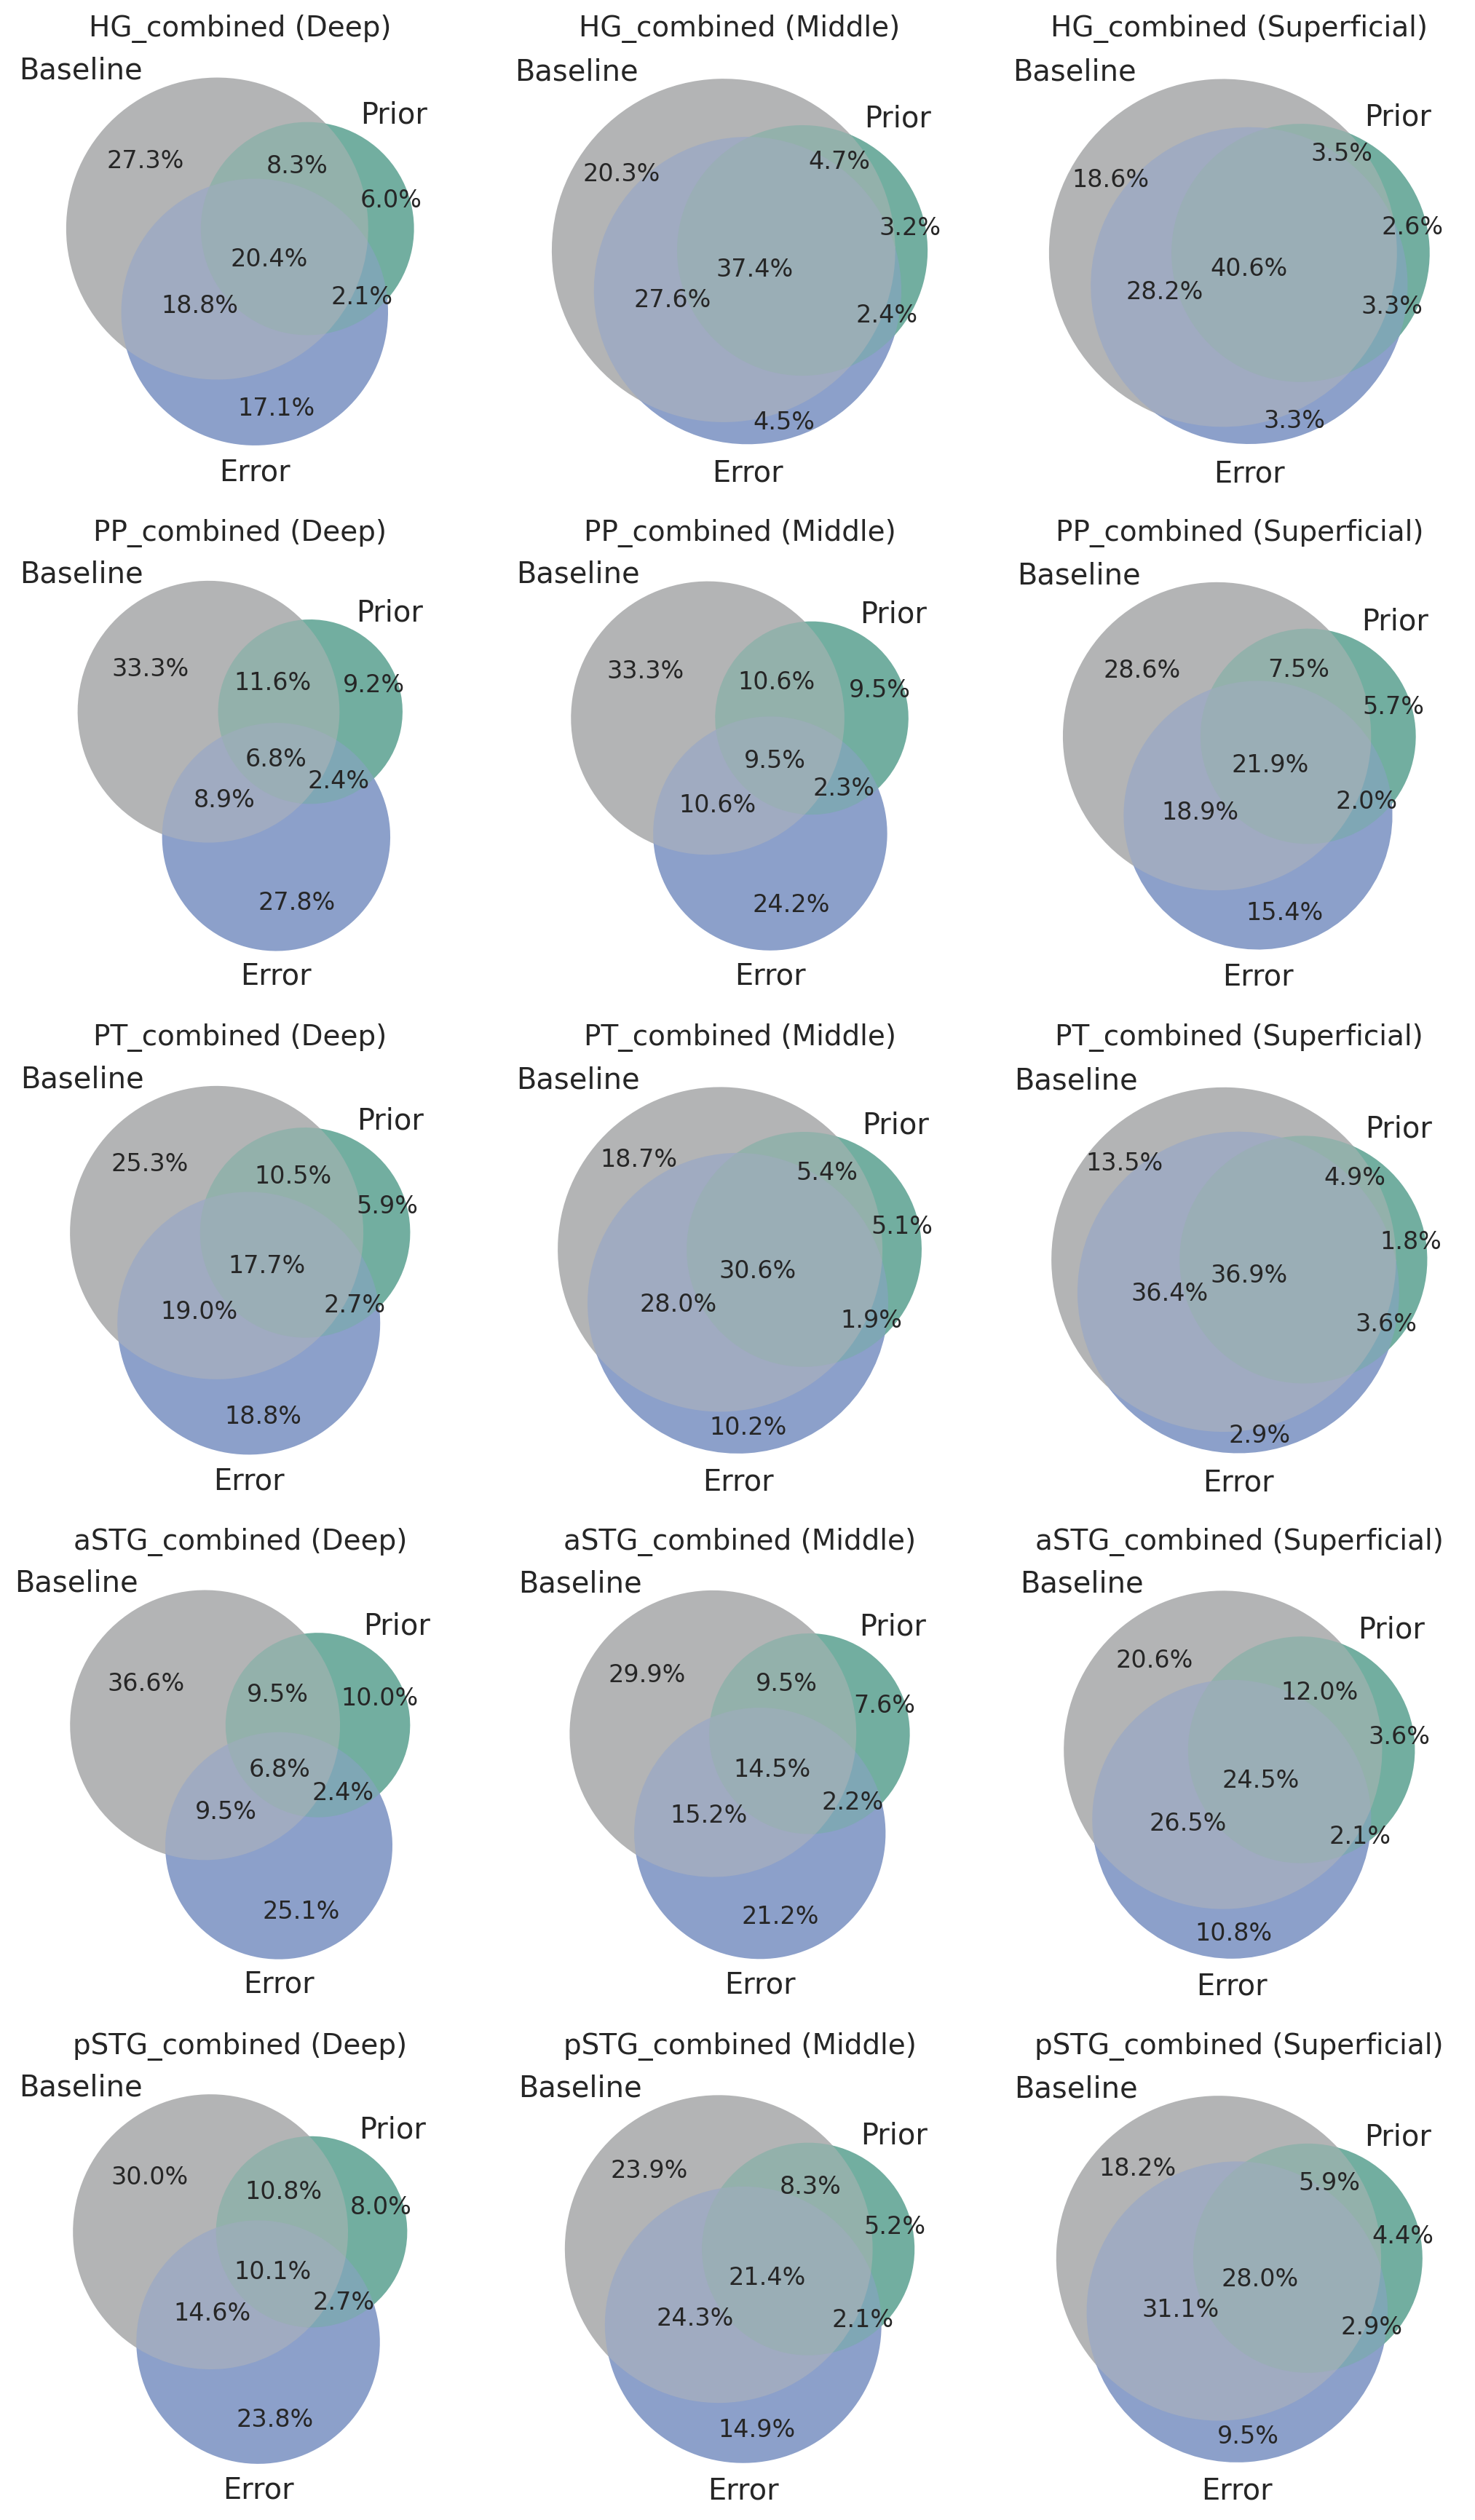

In [892]:
average_df = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle')) 
# average_df = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{corrected_fn}_{cv_fn}(top{topnr})-binned.pickle')) 

## TEMP OLD ONE  BELOW
# average_df = pd.read_pickle(join(mridat_dir, 'split_pred_R2S_df_cv_set3-r2sel15.pickle')) 

average_df_temp = average_df.loc[average_df['roi'].str.contains('combined')]
layers = ['Layer 1', 'Layer 2', 'Layer 3']
layernames = ['Deep', 'Middle', 'Superficial']

# fetch data
# average_df = pd.read_pickle(join(mridat_dir, 'split_pred_R2S_df_noncv_set3-r2sel.pickle'))

# prune dataframe to only 'combined' layer rows
average_df = average_df.loc[average_df['roi'].str.contains('combined')]
average_df = average_df.loc[~average_df['layer'].str.contains('combined')]


# # ## temp remove later
# # average_df['Prior*'] = (average_df['Prior*']-0.0006) * 10
# average_df_temp.loc[average_df_temp['roi'].str.contains('PP') &
#                average_df_temp['layer'].str.contains('1'), 'Prior*'] *= 50


# Create a figure with subplots in one row
fig, axes = plt.subplots(len(average_df_temp['roi'].unique()), len(layers), 
                         figsize=(3.5 * len(layers), 3.5 *  len(average_df_temp['roi'].unique())),
                         dpi=200)


for a, roi in enumerate(average_df_temp['roi'].unique()):
    
    for l, lyr in enumerate(layers):

        # get correct layers and roi data
        set3 = average_df_temp.loc[(average_df_temp['roi'] == roi) &
                                   (average_df_temp['layer'] == lyr)].drop(['pp', 'roi', 'layer'], axis=1).dropna()
        set3 = tuple(set3[col].values for col in set3.columns)
        # bound inpossible values
        set3 = tuple([np.array([max(x, 0.0001) for x in array]) for array in set3])

        # convert to list
        set3 = [i for i in set3]

        # Check if set3 is empty
        if not set3[0].size:
            ax = axes[a, l]  # Select the subplot
            ax.set_facecolor('white')  # Set the background to white
            ax.set_title(f'{roi} ({layernames[l]}) - No Data', fontsize=22)
            continue  # Skip to the next subplot

        # Plot the results in a Venn diagram on the corresponding subplot
        ax = axes[a, l]  # Select the subplot
        fig = varpar.plot_3way_varpartven(set3,
                                          labels=['Baseline',
                                                   'Prior',
                                                   'Error'],
                                          avgfun=_clipped_mean,
                                          alpha=1,
                                          ax=ax,
                                          formatround=3)  # Pass the subplot axis to the plotting function

        varpar.pimpcollors_venn3(fig,colrange=['#b3b4b5', '#72aea0', '#8ca0ca', 
                                               '#93b1ab', '#a0abc1', '#7fa7b5', '#9aaeb6'])  # base - pred
        
#         # Adjust labels based on negatives
#         fig = _check_negatives(fig, threshold=0)
#         fig = _get_cumperc_venn3(fig)
        fig = _get_cumperc_venn3(fig)

        # Set the title of the subplot
        ax.set_title(f'{roi} ({layernames[l]})', fontsize=14)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [285]:
## LAYER RESULTS - split expectations

# 1: deep
# 2: middle
# 3: superficial

# set rois
rois = ['HG_combined', 'PP_combined', 'PT_combined', 'aSTG_combined', 'pSTG_combined']
ttest_pairs = [['Layer 1', 'Layer 2'],
               ['Layer 2', 'Layer 3'],
               ['Layer 1', 'Layer 3']]
# Columns of interest
col_oi = ['base', 'prediction_prior', 'prediction_error', 'base_u_prediction_prior_u_prediction_error', 
          'base*', 'prediction_prior*', 'prediction_error*', 'prediction_prior_n_prediction_error*', 
          'base_n_prediction_prior*', 'base_n_prediction_error*', 'base_n_prediction_prior_n_prediction_error']
# col_oi = ['base*', 'prediction_prior*', 'prediction_error*', 
#           'prediction_prior_n_prediction_error*', 'base_n_prediction_prior*',
#           'base_n_prediction_error*', 'prediction_prior_n_prediction_error*']
# col_oi = ['base*', 'prediction_prior*', 'prediction_error*']

# loading values
scores_fn = 'ANTS_predictors_split_prec_pw_er_lwo_tempsmooth' 
corrected_fn = 'uncorrected'
cv_fn = 'cv(median)' 
threshold_p = 0.05

# initiate pdict
pdict = {}
meandict = {}

# loop over areas
for area in rois:

    print(f'\n--{area}--')
    pdict[area] = {}
    meandict[area] = {}
    
    # load r2s
    average_df_temp = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle'))

    # get roi df
    layers = ['Layer 1', 'Layer 2', 'Layer 3']
    filtered_df = average_df_temp.loc[(average_df_temp['roi'] == area) & (average_df_temp['layer'].isin(layers))]

    # loop over columns of interest
    for c in col_oi:
    
        print(f'{c}')
        pdict[area][c] = []
        meandict[area][c]= []
    
        # loop over pairings
        for pair in ttest_pairs:

            # sellect layer mapping
            df1 = filtered_df.loc[filtered_df['layer'] == pair[0]]
            df2 = filtered_df.loc[filtered_df['layer'] == pair[1]]

            # get diffs
            diff = df1[c].to_numpy() - df2[c].to_numpy()
            meanval = np.mean(diff)
            pval = stats.bootstrap_t_onesample(diff, n_boots=1e5)
            pdict[area][c].append(pval)
            meandict[area][c].append(meanval)

            print(f'{pair[0]} - {pair[1]}\t - mean={meanval:.2e}, p={pval}, pbonf={pval*15}')


--HG_combined--
base
Layer 1 - Layer 2	 - mean=-2.15e-03, p=0.00014, pbonf=0.0021
Layer 2 - Layer 3	 - mean=-2.13e-03, p=0.00022, pbonf=0.0033
Layer 1 - Layer 3	 - mean=-4.27e-03, p=4e-05, pbonf=0.0006000000000000001
prediction_prior
Layer 1 - Layer 2	 - mean=-1.12e-03, p=0.00084, pbonf=0.0126
Layer 2 - Layer 3	 - mean=-1.06e-03, p=0.00116, pbonf=0.0174
Layer 1 - Layer 3	 - mean=-2.17e-03, p=0.00144, pbonf=0.0216
prediction_error
Layer 1 - Layer 2	 - mean=-1.96e-03, p=0.00092, pbonf=0.0138
Layer 2 - Layer 3	 - mean=-1.99e-03, p=0.00058, pbonf=0.0087
Layer 1 - Layer 3	 - mean=-3.95e-03, p=0.0002, pbonf=0.003
base_u_prediction_prior_u_prediction_error
Layer 1 - Layer 2	 - mean=-1.44e-03, p=0.00054, pbonf=0.0081
Layer 2 - Layer 3	 - mean=-2.02e-03, p=0.00044, pbonf=0.0066
Layer 1 - Layer 3	 - mean=-3.46e-03, p=0.0002, pbonf=0.003
base*
Layer 1 - Layer 2	 - mean=-3.91e-05, p=0.70698, pbonf=10.604700000000001
Layer 2 - Layer 3	 - mean=-3.62e-04, p=0.0242, pbonf=0.363
Layer 1 - Layer 3	 - m

Layer 1 - Layer 2	 - mean=5.40e-05, p=0.45826, pbonf=6.8739
Layer 2 - Layer 3	 - mean=4.13e-04, p=0.00182, pbonf=0.0273
Layer 1 - Layer 3	 - mean=4.67e-04, p=0.0002, pbonf=0.003
prediction_prior_n_prediction_error*
Layer 1 - Layer 2	 - mean=-4.36e-06, p=0.94202, pbonf=14.1303
Layer 2 - Layer 3	 - mean=-1.28e-04, p=0.19812, pbonf=2.9718
Layer 1 - Layer 3	 - mean=-1.32e-04, p=0.20092, pbonf=3.0138
base_n_prediction_prior*
Layer 1 - Layer 2	 - mean=-1.66e-05, p=0.86118, pbonf=12.9177
Layer 2 - Layer 3	 - mean=-2.53e-04, p=0.00434, pbonf=0.0651
Layer 1 - Layer 3	 - mean=-2.70e-04, p=0.00048, pbonf=0.0072
base_n_prediction_error*
Layer 1 - Layer 2	 - mean=-2.85e-04, p=0.04962, pbonf=0.7443
Layer 2 - Layer 3	 - mean=-7.48e-04, p=0.00112, pbonf=0.0168
Layer 1 - Layer 3	 - mean=-1.03e-03, p=0.00034, pbonf=0.0051
base_n_prediction_prior_n_prediction_error
Layer 1 - Layer 2	 - mean=-3.94e-04, p=0.00658, pbonf=0.0987
Layer 2 - Layer 3	 - mean=-6.66e-04, p=0.00482, pbonf=0.07229999999999999
Layer 

In [277]:
for coloi in ['base*', 'prediction_prior*', 'prediction_error*', 'prediction_prior_n_prediction_error*',
             'base_n_prediction_prior*', 'base_n_prediction_error*', 'base_n_prediction_prior_n_prediction_error']:

    pvals = [val for area in pdict.keys() for val in pdict[area][coloi]]

    reject_fdr, pvals_fdr, _, _ = statsmodels.stats.multitest.multipletests(pvals, alpha=0.05, method='fdr_bh')
    reject, pvals_bonf, _, _ = statsmodels.stats.multitest.multipletests(pvals, alpha=0.05, method='bonferroni')

    print(f'\nPartition: {coloi}')
    idx = 0
    for area in pdict.keys():
        print(f'--{area}--')
        for pair in ttest_pairs:
#             print(f'{pair[0]} - {pair[1]}\t p(uncorreced):{pvals[idx]:.4f} \t p(fdr):{pvals_fdr[idx]:.4f}\t p(bonf):{pvals_bonf[idx]:.4f}')
            print(f'{pair[0]} - {pair[1]}\t p(uncorreced):{pvals[idx]:.4f} \t p(fdr):{pvals_fdr[idx]:.1e} sig={reject_fdr[idx]}')
            idx += 1


Partition: base*
--HG_combined--
Layer 1 - Layer 2	 p(uncorreced):0.7070 	 p(fdr):8.8e-01 sig=False
Layer 2 - Layer 3	 p(uncorreced):0.0242 	 p(fdr):1.4e-01 sig=False
Layer 1 - Layer 3	 p(uncorreced):0.0452 	 p(fdr):1.4e-01 sig=False
--PP_combined--
Layer 1 - Layer 2	 p(uncorreced):0.4206 	 p(fdr):6.4e-01 sig=False
Layer 2 - Layer 3	 p(uncorreced):0.8257 	 p(fdr):8.8e-01 sig=False
Layer 1 - Layer 3	 p(uncorreced):0.8881 	 p(fdr):8.9e-01 sig=False
--PT_combined--
Layer 1 - Layer 2	 p(uncorreced):0.1690 	 p(fdr):3.6e-01 sig=False
Layer 2 - Layer 3	 p(uncorreced):0.8123 	 p(fdr):8.8e-01 sig=False
Layer 1 - Layer 3	 p(uncorreced):0.7508 	 p(fdr):8.8e-01 sig=False
--aSTG_combined--
Layer 1 - Layer 2	 p(uncorreced):0.2028 	 p(fdr):3.8e-01 sig=False
Layer 2 - Layer 3	 p(uncorreced):0.0309 	 p(fdr):1.4e-01 sig=False
Layer 1 - Layer 3	 p(uncorreced):0.0207 	 p(fdr):1.4e-01 sig=False
--pSTG_combined--
Layer 1 - Layer 2	 p(uncorreced):0.0394 	 p(fdr):1.4e-01 sig=False
Layer 2 - Layer 3	 p(uncorr

### Visualize

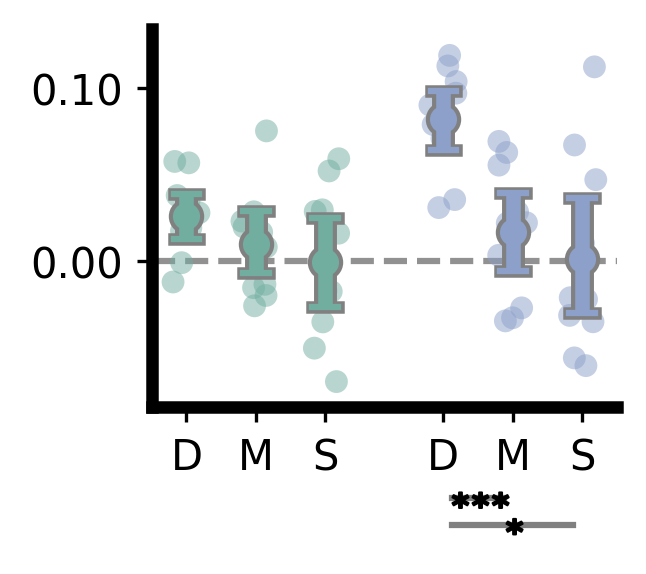

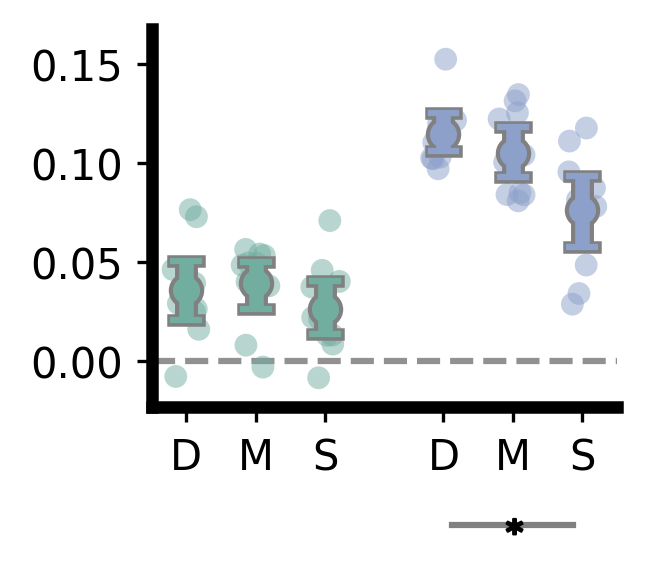

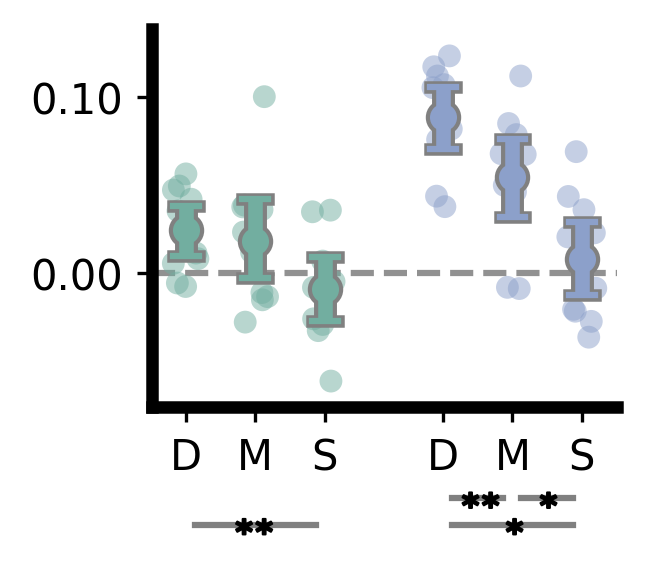

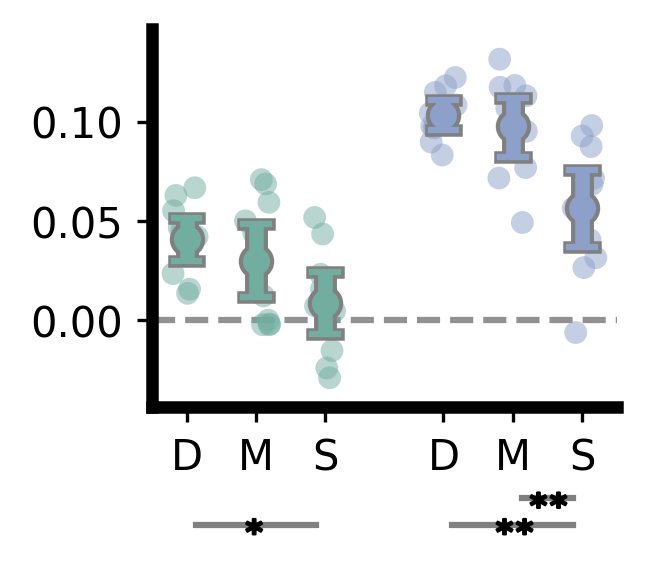

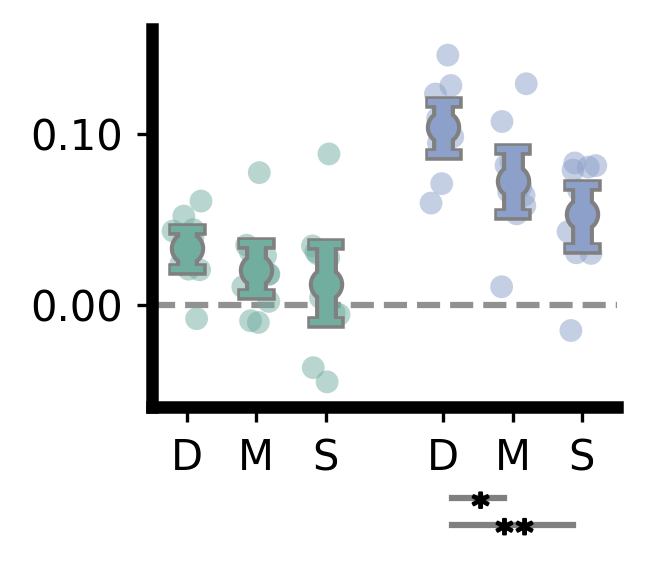

In [145]:
## AND AGAIN THE OTHER WAY ORGAINIZED VERSION OF THIS

def get_star_line(stars, position, sy1='∗', sy2='⋅'):
    star_counts = [s.count(sy1) + s.count(sy2) for s in stars]
    line_parts = []
    for i, count in enumerate(star_counts):
        if i == position:
            original_stars = ''.join(c for c in stars[i] if c in f'{sy1}{sy2}')
            line_parts.append(original_stars)
        else:
            line_parts.append(' ' * count)
    # Now join without adding any extra spaces
    return ' '.join(line_parts)

def get_symbol_line(stars, symbol='-', sy1='∗', sy2='⋅'):
    star_counts = [s.count(sy1) + s.count(sy2) for s in stars]
    if len(stars) <= 1:
        return ''
    return f'{symbol}'.join(' ' * i for i in star_counts)

# sig values # †
# * : p<0.05
# ** : p<0.01
# *** : p<0.001
# † : p_uncorrect<0.05
sigs = {}
sigs['HG_combined'] = {'sig_12': ['prediction_error∗∗∗'], 'sig_23': [], 'sig_13': ['prediction_error∗']}
sigs['PP_combined'] = {'sig_12': [], 'sig_23': [], 'sig_13': ['prediction_error∗']}
sigs['PT_combined'] = {'sig_12': ['prediction_error∗∗'], 'sig_23': ['prediction_error∗'], 'sig_13': ['prediction_prior∗∗','prediction_error∗']}
sigs['aSTG_combined'] = {'sig_12': [], 'sig_23': ['prediction_error∗∗'], 'sig_13': ['prediction_prior∗','prediction_error∗∗']}
sigs['pSTG_combined'] = {'sig_12': ['prediction_error∗'], 'sig_23': [], 'sig_13': ['prediction_error∗∗']}
sigs_colors = {'prediction_prior∗': '#72aea0',
               'prediction_error∗': '#8ca0ca',
               'prediction_prior_n_prediction_error∗': '#7FA7B5',
               'prediction_prior∗∗': '#72aea0',
               'prediction_error∗∗': '#8ca0ca',
               'prediction_prior_n_prediction_error∗∗': '#7FA7B5',
               'prediction_prior∗∗∗': '#72aea0',
               'prediction_error∗∗∗': '#8ca0ca',
               'prediction_prior_n_prediction_error∗∗∗': '#7FA7B5',               
               'prediction_prior†': '#72aea0',
               'prediction_error†': '#8ca0ca',
               'prediction_prior_n_prediction_error†': '#7FA7B5',               
               'prediction_prior⋅': '#72aea0',
               'prediction_error⋅': '#8ca0ca',
               'prediction_prior_n_prediction_error⋅': '#7FA7B5'}
sigs_posx = {'sig_12': 0.427,
               'sig_23': 0.573,
               'sig_13': 0.5}
sigs_posy = {'sig_12': -0.2675,
               'sig_23': -0.2675,
               'sig_13': -0.3375}
sigs_posy = {'sig_12': -0.2475,
               'sig_23': -0.2475,
               'sig_13': -0.3175}

sigs_posx_clm = [-0.28, 0.28]

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from os.path import join
from matplotlib.transforms import blended_transform_factory
import matplotlib.patheffects as path_effects

def smart_jitter(values, center=0, x_range=0.15, min_dist=1.5):
    """Jitter points horizontally around a center while avoiding overlap in both axes."""
    positions = []
    y_spacing = np.std(values) / 100  # small fudge factor
    for y in values:
        tries = 0
        while True:
            x = np.random.uniform(center - x_range, center + x_range)
            too_close = False
            for (x0, y0) in positions:
                if np.sqrt((x - x0)**2 + ((y - y0)/min_dist)**2) < 0.03:
                    too_close = True
                    break
            if not too_close or tries > 100:
                positions.append((x, y))
                break
            tries += 1
    x_jittered, y_jittered = zip(*positions)
    return np.array(x_jittered)

scores_fn = 'ANTS_predictors_split_prec_pw_er_lwo_tempsmooth' 
corrected_fn = 'uncorrected'
cv_fn = 'cv(median)' 
threshold_p = 0.05

# outline
outline = True
show_ylabel = False

# set capwith
errwidth = 0.1  # Adjust this value to change cap width

# set rois
rois = ['HG_combined', 'PP_combined', 'PT_combined', 'aSTG_combined', 'pSTG_combined']
for area in rois:

    average_df_temp = pd.read_pickle(join(mridat_dir, f'R2S_{scores_fn}_{handle_negatives}_{corrected_fn}_{cv_fn}(p{threshold_p:.0e})-binned.pickle'))

    layers = ['Layer 1', 'Layer 2', 'Layer 3']
    filtered_df = average_df_temp.loc[(average_df_temp['roi'] == area) & (average_df_temp['layer'].isin(layers))]

    plt.figure(figsize=(2, 2), dpi=300)

    # old including baseline
#     colors = ['#b3b4b5', '#72aea0', '#8ca0ca']
#     colors_light = ['#D9DADA', '#B9D7D0', '#C6D0E5']
#     labels = ['Baseline Model', 'Priors', 'Errors']
#     columns = ['base*', 'prediction_prior*', 'prediction_error*']
#     x_offsets = [-0.2, 0.0, 0.2]
    
    factor_colors = ['#72aea0', '#8ca0ca']
    colors_light = ['#B9D7D0', '#C6D0E5']
    labels = ['Priors', 'Errors']
    columns = ['prediction_prior*', 'prediction_error*']
#     columns = ['base_n_prediction_prior*', 'base_n_prediction_error*']
    x_offsets = [-0.15, 0.15]
    layer_offsets = [-0.27, 0, 0.27]  # bar offsets within each factor
    
#     colors = ['#72aea0', '#8ca0ca']
#     colors_light = ['#B9D7D0', '#C6D0E5']
#     labels = ['Priors', 'Errors']
#     columns = ['prediction_prior*', 'prediction_error*']
#     x_offsets = [-0.1, 0.1]

    for f_idx, (col, factor, f_color) in enumerate(zip(columns, factors, factor_colors)):
        for l_idx, (layer, offset) in enumerate(zip(layers, layer_offsets)):
            layer_data = filtered_df.loc[filtered_df['layer'] == layer, col] * 100
            x_pos = f_idx + offset

            # scatter individual datapoints
            x_jitter = smart_jitter(layer_data.to_numpy(), center=x_pos, x_range=0.055, min_dist=2.0)
            plt.scatter(x_jitter, layer_data, s=30,
                        color=f_color, edgecolors='none', alpha=0.5)

            # CI line
            ci_low, ci_high = stats.bootstrap_ci(layer_data.to_numpy())
            median_val = np.mean(layer_data)

            if outline:
                plt.plot(x_pos, median_val, 'o', color=f_color, markersize=7.5,
                         markeredgewidth=1.0, markeredgecolor='grey', zorder=3)
                plt.plot([x_pos, x_pos], [ci_low, ci_high],
                         color='grey', lw=5.5, zorder=2, solid_capstyle='butt')
                plt.plot([x_pos, x_pos], [ci_low, ci_high],
                         color=f_color, lw=3.5, zorder=3, solid_capstyle='butt')
                # caps
                for y_val in [ci_low, ci_high]:
                    plt.plot([x_pos - errwidth/2, x_pos + errwidth/2],
                             [y_val, y_val], color='grey', lw=3, zorder=2)
                    plt.plot([x_pos - errwidth/2, x_pos + errwidth/2],
                             [y_val, y_val], color=f_color, lw=1.5, zorder=3)
            else:
                plt.plot(x_pos, median_val, 'o', color=f_color, markersize=7.5)
                plt.plot([x_pos, x_pos], [ci_low, ci_high],
                         color=f_color, lw=4.5, solid_capstyle='butt')
                for y_val in [ci_low, ci_high]:
                    plt.plot([x_pos - errwidth/2, x_pos + errwidth/2],
                             [y_val, y_val], color=f_color, lw=1.5)

    ax = plt.gca()
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(3)
    ax.spines['bottom'].set_linewidth(3)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

    tick_positions = []
    tick_labels = []
    for f_idx in range(len(factors)):
        for offset, lbl in zip(layer_offsets, ['D', 'M', 'S']):
            tick_positions.append(f_idx + offset)
            tick_labels.append(lbl)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=10)

    
    ylimmax = (np.max(filtered_df[columns]) * 100) + 0.015
    ylimmin = (np.min(filtered_df[columns]) * 100) - 0.015
    ax.set_ylim(ylimmin, ylimmax)

    # horizontal line at 0
    plt.axhline(0, linestyle='--', color='#919191', alpha=1, linewidth=1.5, zorder=0)

    for idx, label in enumerate(labels):
        plt.plot([], [], color=colors[idx], lw=4, label=label)
    

 # === Draw layer comparison lines below plot, outside data space ===

    # lookup sig values
    sig_lookup = sigs.get(area, {})

    # Get axis and figure transform to position below axis area
    trans = blended_transform_factory(ax.transData, ax.transAxes)

    y_pos_main = -0.24  # controls vertical position under the x-axis (play with this value)
    spacing = 0.07     # vertical spacing for non-overlapping long line
    x_spacing = 0.035

    # Comparison: Deep–Middle (0–1)
    if len(sig_lookup['sig_12']) > 0: # check if any sig
        
        # check all the columns
        for c_idx, c in enumerate(columns):
            if any(re.match(f'^{c}.*', item) for item in sig_lookup['sig_12']):
                ax.plot([layer_offsets[0]+c_idx+x_spacing, layer_offsets[1]+c_idx-x_spacing], [y_pos_main, y_pos_main], transform=trans, color='grey', lw=1.5, clip_on=False)

    # Comparison: Middle–Superficial (1–2)
    if len(sig_lookup['sig_23']) > 0: # check if any sig
        
        # check all the columns
        for c_idx, c in enumerate(columns):
            if any(re.match(f'^{c}.*', item) for item in sig_lookup['sig_23']):
                ax.plot([layer_offsets[1]+c_idx+x_spacing, layer_offsets[2]+c_idx-x_spacing], [y_pos_main, y_pos_main], transform=trans, color='grey', lw=1.5, clip_on=False)

    # Comparison: Deep–Superficial (0–2), offset slightly lower
    if len(sig_lookup['sig_13']) > 0: # check if any sig
        
        # check all the columns
        for c_idx, c in enumerate(columns):
            if any(re.match(f'^{c}.*', item) for item in sig_lookup['sig_13']):
                ax.plot([layer_offsets[0]+c_idx+x_spacing, layer_offsets[2]+c_idx-x_spacing], [y_pos_main - spacing, y_pos_main - spacing], transform=trans, color='grey', lw=1.5, clip_on=False)

    # Optional: extend figure bottom margin to make space
    plt.subplots_adjust(bottom=0.25)
    
    ## set significance marking
    for comp in ['sig_12', 'sig_23', 'sig_13']:
        stars = sig_lookup.get(comp, [])
        for st_idx, star in enumerate(stars):
            
            # dont combine stars, just present 1
            constructtxt = get_star_line([star], 0)
            
            # check all the columns
            for c_idx, c in enumerate(columns):
                # check if column is star
                if re.match(f"^{re.escape(c.rstrip('*'))}.*", star):
            
                    posx = sigs_posx[comp] + sigs_posx_clm[c_idx]
            
                    txt = ax.text(posx, sigs_posy[comp], constructtxt, horizontalalignment='center', verticalalignment='center', 
                                  transform=ax.transAxes, fontsize=8, fontweight='bold', color='black', fontname='monospace')
                    txt.set_path_effects([
                                    path_effects.Stroke(linewidth=0.5, foreground='black'),
                                    path_effects.Normal()
                                    ])

    # adjust labeling
    if show_ylabel:
        plt.ylabel('Cross-validated R² (%)', fontsize=10)
    else:
        ax.set_ylabel(None)
        ax.yaxis.set_label_coords(-0.1, 0.5)  # pushes invisible label space out, optional
        area = f'splitpred_{area}_noYlabel'
    
    
    # save
    outname_base = join('visualisation', f'layerresults_split_{area}_outlined' if outline else f'layerresults_{area}')
#     plt.savefig(f'{outname_base}_v2.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{outname_base}_v2.pdf', bbox_inches='tight')
#     plt.savefig(f'{outname_base}_v2.jpg', bbox_inches='tight', dpi=300)
        
    plt.show()
